In [4]:
import pandas as pd
import glob as glob
from Bio.Seq import Seq
import os
import numpy as np
from Bio import motifs
from matplotlib import pyplot as plt
from utils import draw_tf_heatmap , annotate_region
import dask.dataframe as dd
import importlib
import utils
from utils import draw_tf_heatmap , annotate_region
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

In [5]:
data_test='cisbp'
inputfolder = '/data2st2/junyi/output/atac1112/tobiasbam/'

In [6]:
files =glob.glob('/data2st1/junyi/scenic/mouse/motif/singletons/*')
outdir = '/data2st1/junyi/scenic/mouse/motif/merged_cluster'
tbffile = '/data2st1/junyi/scenic/mouse/motif/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl'
TFoutdir = '/data2st1/junyi/output/atac1112/snregulation/'
df_important_TF = pd.read_csv(f'/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/significant_TFlist.csv',header=None)
df_important_TF.columns=['TF']
df_tbffile = pd.read_csv(tbffile, sep='\t')

/tmp/ipykernel_1770676/4282565885.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tbffile = pd.read_csv(tbffile, sep='\t')


In [7]:
def add_columns(results):
    if 'MC_MW_change' in results.columns:
        results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
        results['log2FC'] = results['MC_MW_change']
    elif 'log2FC_Weighted' in results.columns:
        results['Direction'] = results['log2FC_Weighted'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    if 'ctname' in results.columns:
        results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    else:
        results['ctname'] = results['Region Subclass']
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    if ('FDR' not in results.columns) and ('MC_MW_pvalue' in results.columns):
        results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results


In [8]:
df = df_tbffile
motif_similarity_fdr = 0.001,
orthologous_identity_threshold  = 0.0
df.rename(columns={'#motif_id':"MotifID",
                    'gene_name':"TF",
                    'motif_similarity_qvalue': "MotifSimilarityQvalue",
                    'orthologous_identity': "OrthologousIdentity",
                    'description': "Annotation" }, inplace=True)
df = df[(df["MotifSimilarityQvalue"] <= motif_similarity_fdr) &
        (df["OrthologousIdentity"] >= orthologous_identity_threshold)]


In [9]:
df_direct_annot = df[df['Annotation'] == 'gene is directly annotated']
#df_direct_annot = df_direct_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

df_direct_annot.to_csv(os.path.join(outdir, 'motif_TF_annotated.tsv'), index=False)
df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']
df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"
dict_id2tf = dict(zip(df_direct_annot['soure_name'], df_direct_annot['TF']))
motif_similarity_annot = df[df['Annotation'].str.contains('similar') & ~df['Annotation'].str.contains('orthologous')]
#motif_similarity_annot = motif_similarity_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

direct_motif_TFs = df_direct_annot[df_direct_annot.TF.isin(df_important_TF.TF)]
direct_motif_TFs = direct_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


/tmp/ipykernel_1770676/747042444.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']
/tmp/ipykernel_1770676/747042444.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"


In [10]:
# direct_motifs = []
# names = []
# parsed_TFs= []
# for f in files:
#     bn = os.path.basename(f).removesuffix('.cb')
#     if bn not in direct_motif_TFs['MotifID'].values:
#         #print(f"Skipping {bn} as it is not in the important TF list.")
#         continue
#     tf_tmp = direct_motif_TFs[direct_motif_TFs['MotifID'] == bn].TF.values[0]
#     try:
#         with open(f) as handle:
#             m = motifs.read(handle, "ClusterBuster")
#             direct_motifs.append(m)
#             names.append(bn)
#             parsed_TFs.append(tf_tmp)
#             if 'MA0859.1' in record.name:
#                 print("here")

#     except ValueError:
#         with open(f) as handle:
#             records = motifs.parse(handle, "ClusterBuster")
#             for record in records:
#                 if 'MA0859.1' in record.name:
#                     print("here")
#                 record.name = bn+"#"+record.name
#                 direct_motifs.append(record)
#                 names.append(record.name)
#                 parsed_TFs.append(tf_tmp)

# mapdict = dict(zip(names, parsed_TFs))

In [11]:
extended_motif_TFs = motif_similarity_annot[motif_similarity_annot.TF.isin(df_important_TF.TF)]
extended_motif_TFs = extended_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

In [12]:
TOBIAS_Rsults = glob.glob(f'{inputfolder}/*{data_test}*/*.bw/bindetect_results.xlsx')

In [13]:
TOBIAS_distances = glob.glob(f'{inputfolder}/*{data_test}*/*.bw/bindetect_distances.txt')

In [14]:
df_distance = pd.read_csv(TOBIAS_distances[0],sep='\t')
df_distance.index = df_distance.columns

In [15]:
def calculate_medoids(D, labels):
    """
    Calculate the medoid for each cluster based on a precomputed distance matrix.

    Parameters:
    D (numpy.ndarray): A square symmetric matrix of pairwise distances.
    labels (numpy.ndarray): An array of cluster labels for each point.

    Returns:
    dict: A dictionary where keys are cluster labels and values are the indices of the medoids.
    """
    unique_labels = np.unique(labels)
    medoids = {}
    
    for k in unique_labels:
        # 1. Get indices of points in the current cluster
        cluster_indices = np.where(labels == k)[0]
        
        # 2. Extract the sub-distance matrix for the current cluster
        cluster_distance_matrix = D[np.ix_(cluster_indices, cluster_indices)]
        
        # 3. Calculate the sum of distances for each point in the cluster
        sum_of_distances = np.sum(cluster_distance_matrix, axis=1)
        
        # 4. Find the index of the point with the minimum sum of distances *within the cluster*
        medoid_index_in_cluster = np.argmin(sum_of_distances)
        
        # 5. Map this index back to the original global index
        global_medoid_index = cluster_indices[medoid_index_in_cluster]
        
        medoids[k] = global_medoid_index
        
    return medoids

def get_motif_medoids(df_distance,method='average',threshold=0.5):
    linkage_mat = linkage(squareform(df_distance), method)
    labels = fcluster(linkage_mat, threshold, criterion="distance")		#ordering of the dendrogram
    dict_motif_clusters = dict(zip(df_distance.columns,labels))
    dict_cluster_mot = calculate_medoids(df_distance.values,labels)
    dict_cluster_name = {}
    for key in dict_cluster_mot.keys():
        dict_cluster_name[key] = df_distance.columns[dict_cluster_mot[key]]
    dit_motif_to_medoid = {}
    for key in dict_motif_clusters.keys():
        dit_motif_to_medoid[key] = dict_cluster_name[dict_motif_clusters[key]]
    return dit_motif_to_medoid


# Merge all TOBIAS results on TF level

In [16]:
%%capture
# ignore cell outputs for this cell
results = pd.DataFrame()
full = pd.DataFrame()
full_results = pd.DataFrame()
for file in TOBIAS_Rsults:
    print(file)
    df_tobias = pd.read_excel(file)
    ctname = file.split('/')[-2].replace('_MC_footprints.bw','')
    region = ctname[:3]
    df_tobias['ctname'] = ctname
    df_tobias['MotifID'] = df_tobias['name'].str.split('#').str[0]
    df_tobias['source_name'] = df_tobias['name'].str.split('#').str[1]
    df_tobias['TF']=df_tobias['source_name'].map(dict_id2tf)
    df_tobias.dropna(inplace=True)
    df_tobias['abs_change'] = df_tobias['MC_MW_change'].abs()

    distance_file = file.replace('bindetect_results.xlsx','bindetect_distances.txt')
    df_distance = pd.read_csv(distance_file,sep='\t')
    df_distance.index = df_distance.columns
    motif2medoids = get_motif_medoids(df_distance)

    df_tobias['motifmedoid'] = df_tobias['output_prefix'].map(motif2medoids).values
    #df_tobias.sort_values(by='abs_change', ascending=False, inplace=True)
    #df_tobias.drop_duplicates(subset=['TFID','TF'], inplace=True)
    # df_tobias["TFexpand"] = df_tobias["TF"].str.split(",\s*")  # split by comma + optional space
    # df_expanded = df_tobias.explode("TFexpand").reset_index(drop=True)
    full_results = pd.concat([full_results, df_tobias], axis=0)
    #results = pd.concat([results, df_expanded_mean], axis=0)



In [17]:
full_results_sub=full_results[full_results.output_prefix==full_results.motifmedoid]

In [18]:
full_results_back = full_results.copy()

In [19]:
full_results = full_results_sub

In [20]:
logfiles =[
'/home/junyichen/logs/17binplotAGG.sh.2026-01-05-16-05-40.out',
'/home/junyichen/logs/17binplotAGG.sh.2026-01-04-10-35-26.out',
'/home/junyichen/logs/17binplotAGG.sh.2026-01-02-17-38-29.out',
]

In [21]:
specific_word = '[STATS]	FPD ('
lines = []
remove_chars = "[]();\t:"
for logfile in logfiles:
    with open(logfile, 'r') as infile:
        filtered_lines = list(map(str.strip, filter(lambda line: specific_word in line, infile)))
    lines+=filtered_lines

In [22]:
specific_word = '[STATS]\tFPD ('
lines = []

remove_chars = "[]();\t:"
table = str.maketrans("", "", remove_chars)

for logfile in logfiles:
    with open(logfile, "r") as infile:
        filtered_lines = [
            line.translate(table).replace(",", " ").strip()
            for line in infile
            if specific_word in line
        ]
    lines += filtered_lines


In [23]:
rows = [ln.split() for ln in lines]

df = pd.DataFrame(rows)


In [24]:
df_score=df.iloc[:,4:]

In [25]:
df_score.columns=['celltype','motif','width','bgscore','midscore','tfbsscore']

In [26]:
df_score['Region Subclass Condition'] = df_score['celltype'].str.replace('_corrected',"")
df_score['Condtion']=df_score['Region Subclass Condition'].str.split("_").str[-1]
df_score['Region Subclass'] = df_score['Region Subclass Condition'].str[:-3]
df_score['Region Subclass'] = df_score['Region Subclass'].str.replace("HIP","HPF")
df_score['motif'] = df_score['motif'].str.replace("_all","")

/tmp/ipykernel_1770676/226307273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score['Region Subclass Condition'] = df_score['celltype'].str.replace('_corrected',"")
/tmp/ipykernel_1770676/226307273.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score['Condtion']=df_score['Region Subclass Condition'].str.split("_").str[-1]
/tmp/ipykernel_1770676/226307273.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

In [27]:
# df_score['Region Subclass'] = df_score['Region Subclass'].str.replace('HPF_HPF',"")
# df_score['Region Subclass'] = df_score['Region Subclass'].str.replace('AMY_AMY',"")
# df_score['Region Subclass'] = df_score['Region Subclass'].str.replace('PFC_PFC',"")

In [28]:
full_results_sub = add_columns(full_results_sub)

In [29]:
df_merge = pd.merge(df_score,full_results_sub,how='right',left_on=['Region Subclass','motif'],right_on=['Region Subclass','motifmedoid'])

In [30]:
df_merge['bgscore'] = df_merge['bgscore'].astype(float)
df_merge['midscore'] = df_merge['midscore'].astype(float)
df_merge['tfbsscore'] = df_merge['tfbsscore'].astype(float)
df_merge['width'] = df_merge['width'].astype(float)

In [35]:
df_merge

,celltype,motif,width,bgscore,midscore,tfbsscore,Region Subclass Condition,Condtion,Region Subclass,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
0,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,8.0,0.00501,-0.00866,-0.01367,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
1,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,10.0,0.00525,-0.00857,-0.01382,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
2,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,12.0,0.00574,-0.01065,-0.01639,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
3,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,14.0,0.00614,-0.01136,-0.01750,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
4,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,16.0,0.00618,-0.00944,-0.01562,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329987,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,40.0,0.00699,0.01418,0.00719,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2
329988,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,42.0,0.00722,0.01341,0.00618,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2
329989,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,44.0,0.00709,0.01336,0.00628,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2
329990,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,46.0,0.00698,0.01326,0.00629,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2


In [36]:
df_merge_shallow = df_merge[df_merge.width<14]

In [37]:
df_merge_mean = df_merge_shallow.groupby(['Region Subclass','Condtion','motif']).max().reset_index()

In [38]:
df_merge_bsfilterer = df_merge_mean[(df_merge_mean.tfbsscore<0)]

In [39]:
df_merge_bsfilterer

,Region Subclass,Condtion,motif,celltype,width,bgscore,midscore,tfbsscore,Region Subclass Condition,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
1,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_1.10cisbp__M00421_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00207,-0.00006,-0.00200,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_1.10cisbp__M00421_None,...,Up,0.00379,M,Hoxc10,Glut,8.843790e-05,AMY_Cav1_Frmpd1_Glut,AMY,Up,AMY_Cav1_Frmpd1_Glut
2,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_1.9cisbp__M00389_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00341,-0.00524,-0.00849,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_1.9cisbp__M00389_None,...,Up,0.00390,M,Hoxc13,Glut,6.505940e-05,AMY_Cav1_Frmpd1_Glut,AMY,Up,AMY_Cav1_Frmpd1_Glut
3,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_11.2cisbp__M00818_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00167,-0.00819,-0.00934,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_11.2cisbp__M00818_None,...,Down,-0.06790,M,Nr4a2,Glut,6.851560e-94,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
4,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_111.3cisbp__M00991_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.04140,-0.05189,-0.09021,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_111.3cisbp__M00991_None,...,Down,-0.03408,M,Creb1,Glut,7.403020e-46,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
5,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_111.3cisbp__M01810_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.02873,-0.05462,-0.08156,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_111.3cisbp__M01810_None,...,Down,-0.02333,M,Jdp2,Glut,1.525560e-36,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13044,PFC_Pericyte,MW,metacluster_5.1cisbp__M08039_None,PFC_Pericyte_MW_corrected,12.0,0.00395,-0.01231,-0.01457,PFC_Pericyte_MW,metacluster_5.1cisbp__M08039_None,...,Down,-0.00107,M,Rela,NN,2.545980e-01,Pericyte,PFC,Down,Pericyte
13045,PFC_Pericyte,MW,metacluster_67.2cisbp__M00153_None,PFC_Pericyte_MW_corrected,12.0,0.00965,-0.00320,-0.01055,PFC_Pericyte_MW,metacluster_67.2cisbp__M00153_None,...,Up,0.01767,M,E2f3,NN,3.674350e-11,Pericyte,PFC,Up,Pericyte
13046,PFC_Pericyte,MW,metacluster_67.2cisbp__M01011_None,PFC_Pericyte_MW_corrected,12.0,0.02137,-0.07777,-0.09913,PFC_Pericyte_MW,metacluster_67.2cisbp__M01011_None,...,Up,0.00519,M,Foxn4,NN,1.352490e-04,Pericyte,PFC,Up,Pericyte
13048,PFC_Pericyte,MW,metacluster_8.2cisbp__M01307_None,PFC_Pericyte_MW_corrected,12.0,0.00194,0.00136,-0.00034,PFC_Pericyte_MW,metacluster_8.2cisbp__M01307_None,...,Down,-0.01557,M,Runx2,NN,6.134220e-11,Pericyte,PFC,Down,Pericyte


# Vizualize the results as heatmap

In [ ]:
# full_selected.sort_values(by=['abs_change','total_tfbs'], ascending=[False,False], inplace=True)
# full_selected
# full_selected.drop_duplicates(subset=['Region Subclass','cluster'])

In [40]:
full_results = add_columns(full_results)
#avg_results = add_columns(results)
#full_results_filtered = full_results[full_results['MC_MW_highlighted']==True]
# full_results_filtered = full_results[full_results.FDR < 0.05]
# full_results_filtered['absLog2FC'] = full_results_filtered['log2FC'].abs()
# full_results_filtered.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
# full_results_filtered.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)
#results=avg_results[avg_results.FDR <0.05]
results=full_results[full_results.FDR < 0.05]
results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])
results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
results['Regulation']=results['Regulation'].astype(float)

/tmp/ipykernel_3554842/971198905.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])
/tmp/ipykernel_3554842/971198905.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
/tmp/ipykernel_3554842/971198905.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

In [41]:
results.sort_values(by=['abs_change','total_tfbs'], ascending=[False,False], inplace=True)
results_back = results.copy()

/tmp/ipykernel_3554842/1508574533.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results.sort_values(by=['abs_change','total_tfbs'], ascending=[False,False], inplace=True)


In [42]:
results.drop_duplicates(subset=['Region Subclass','cluster'],inplace=True)

/tmp/ipykernel_3554842/4274392065.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results.drop_duplicates(subset=['Region Subclass','cluster'],inplace=True)


In [43]:
results['name_tf'] = results['TF']+"_"+results['motifmedoid']

/tmp/ipykernel_3554842/2235640212.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['name_tf'] = results['TF']+"_"+results['motifmedoid']


In [66]:
df_merge_bsfilterer.loc[:,['Region Subclass','motif']]

,Region Subclass,motif
1,AMY_AMY_Cav1_Frmpd1_Glut,metacluster_1.10cisbp__M00421_None
2,AMY_AMY_Cav1_Frmpd1_Glut,metacluster_1.9cisbp__M00389_None
3,AMY_AMY_Cav1_Frmpd1_Glut,metacluster_11.2cisbp__M00818_None
4,AMY_AMY_Cav1_Frmpd1_Glut,metacluster_111.3cisbp__M00991_None
5,AMY_AMY_Cav1_Frmpd1_Glut,metacluster_111.3cisbp__M01810_None
...,...,...
13044,PFC_Pericyte,metacluster_5.1cisbp__M08039_None
13045,PFC_Pericyte,metacluster_67.2cisbp__M00153_None
13046,PFC_Pericyte,metacluster_67.2cisbp__M01011_None
13048,PFC_Pericyte,metacluster_8.2cisbp__M01307_None


In [45]:
df_merge_bsfilterer.drop_duplicates(inplace=True)

/tmp/ipykernel_3554842/954353739.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merge_bsfilterer.drop_duplicates(inplace=True)


In [46]:
df_merge_bsfilterer

,Region Subclass,Condtion,motif,celltype,width,bgscore,midscore,tfbsscore,Region Subclass Condition,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
1,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_1.10cisbp__M00421_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00207,-0.00006,-0.00200,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_1.10cisbp__M00421_None,...,Up,0.00379,M,Hoxc10,Glut,8.843790e-05,AMY_Cav1_Frmpd1_Glut,AMY,Up,AMY_Cav1_Frmpd1_Glut
2,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_1.9cisbp__M00389_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00341,-0.00524,-0.00849,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_1.9cisbp__M00389_None,...,Up,0.00390,M,Hoxc13,Glut,6.505940e-05,AMY_Cav1_Frmpd1_Glut,AMY,Up,AMY_Cav1_Frmpd1_Glut
3,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_11.2cisbp__M00818_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00167,-0.00819,-0.00934,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_11.2cisbp__M00818_None,...,Down,-0.06790,M,Nr4a2,Glut,6.851560e-94,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
4,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_111.3cisbp__M00991_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.04140,-0.05189,-0.09021,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_111.3cisbp__M00991_None,...,Down,-0.03408,M,Creb1,Glut,7.403020e-46,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
5,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_111.3cisbp__M01810_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.02873,-0.05462,-0.08156,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_111.3cisbp__M01810_None,...,Down,-0.02333,M,Jdp2,Glut,1.525560e-36,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13044,PFC_Pericyte,MW,metacluster_5.1cisbp__M08039_None,PFC_Pericyte_MW_corrected,12.0,0.00395,-0.01231,-0.01457,PFC_Pericyte_MW,metacluster_5.1cisbp__M08039_None,...,Down,-0.00107,M,Rela,NN,2.545980e-01,Pericyte,PFC,Down,Pericyte
13045,PFC_Pericyte,MW,metacluster_67.2cisbp__M00153_None,PFC_Pericyte_MW_corrected,12.0,0.00965,-0.00320,-0.01055,PFC_Pericyte_MW,metacluster_67.2cisbp__M00153_None,...,Up,0.01767,M,E2f3,NN,3.674350e-11,Pericyte,PFC,Up,Pericyte
13046,PFC_Pericyte,MW,metacluster_67.2cisbp__M01011_None,PFC_Pericyte_MW_corrected,12.0,0.02137,-0.07777,-0.09913,PFC_Pericyte_MW,metacluster_67.2cisbp__M01011_None,...,Up,0.00519,M,Foxn4,NN,1.352490e-04,Pericyte,PFC,Up,Pericyte
13048,PFC_Pericyte,MW,metacluster_8.2cisbp__M01307_None,PFC_Pericyte_MW_corrected,12.0,0.00194,0.00136,-0.00034,PFC_Pericyte_MW,metacluster_8.2cisbp__M01307_None,...,Down,-0.01557,M,Runx2,NN,6.134220e-11,Pericyte,PFC,Down,Pericyte


In [47]:
df_selected = df_merge_bsfilterer.loc[:,['Region Subclass','motif']].drop_duplicates()

In [48]:
df_selected.rename({'motif':'motifmedoid'},axis=1,inplace=True)

In [49]:
results = pd.merge(results,df_selected,how='inner',left_on=['Region Subclass','motifmedoid'],right_on=['Region Subclass','motifmedoid'])

In [50]:
results

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Neurotransmitter,Region Subclass,FDR,Subclass,Region,status,celltype.L2,nlogp,Regulation,name_tf
0,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,42058,0.14791,8874,0.16927,10695,-0.41308,...,Glut,PFC_PFC_L4-5_IT_Glut,5.641080e-193,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,-192.248638,-1.0,Jund_metacluster_137.2cisbp__M01001_None
1,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,49246,0.15978,15728,0.17790,17378,-0.36419,...,Glut,PFC_PFC_L2-3_IT_Glut,2.094710e-188,PFC_L2-3_IT_Glut,PFC,Down,PFC_L2-3_IT_Glut,-187.678876,-1.0,Jund_metacluster_137.2cisbp__M01001_None
2,metacluster_14.17cisbp__M02818_None,metacluster_14.17#cisbp__M02818,None,C_metacluster_128.2#cisbp__M01721,14984,0.23914,3972,0.20986,3605,0.34449,...,Glut,PFC_PFC_L4-5_IT_Glut,5.805490e-160,PFC_L4-5_IT_Glut,PFC,Up,PFC_L4-5_IT_Glut,159.236161,1.0,Bhlhe40_metacluster_14.17cisbp__M02818_None
3,metacluster_121.1cisbp__M00820_None,metacluster_121.1#cisbp__M00820,None,C_metacluster_121.1#cisbp__M00820,33482,0.09209,5288,0.08048,4659,0.33697,...,Glut,PFC_PFC_L2-3_IT_Glut,3.463140e-177,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,176.460530,1.0,Rorb_metacluster_121.1cisbp__M00820_None
4,metacluster_121.1cisbp__M01297_None,metacluster_121.1#cisbp__M01297,None,C_metacluster_121.1#cisbp__M01297,34228,0.07565,4394,0.06548,3941,0.33097,...,Glut,PFC_PFC_L2-3_IT_Glut,1.863860e-179,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,178.729587,1.0,Esr2_metacluster_121.1cisbp__M01297_None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4261,metacluster_42.4transfac_public__M00510_None,metacluster_42.4#transfac_public__M00510,None,C_metacluster_42.4#transfac_public__M00510,18803,0.21365,2856,0.21721,2771,-0.00040,...,GABA,AMY_AMY_Npas1_Rgs12_GABA,3.902330e-03,AMY_Npas1_Rgs12_GABA,AMY,Down,AMY_Npas1_Rgs12_GABA,-2.408676,-1.0,Lhx3_metacluster_42.4transfac_public__M00510_None
4262,metacluster_118.1cisbp__M00545_None,metacluster_118.1#cisbp__M00545,None,C_metacluster_118.1#cisbp__M00545,18297,0.16651,8958,0.16630,9219,0.00014,...,NN,AMY_OPC,4.554010e-02,OPC,AMY,Up,OPC,1.341606,1.0,Pou6f1_metacluster_118.1cisbp__M00545_None
4263,metacluster_67.2cisbp__M00153_None,metacluster_67.2#cisbp__M00153,None,C_metacluster_67.2#cisbp__M00154,1316,5.15344,175,7.84705,289,-0.00012,...,NN,HPF_MOL-3,2.893230e-02,MOL-3,HPF,Down,MOL-3,-1.538617,-1.0,E2f3_metacluster_67.2cisbp__M00153_None
4264,metacluster_19.7cisbp__M00190_None,metacluster_19.7#cisbp__M00190,None,C_metacluster_19.7#cisbp__M00190,2055,1.12685,987,1.16055,1014,0.00007,...,GABA,HPF_HPF_Sncg_GABA,3.465330e-02,HPF_Sncg_GABA,HPF,Up,HPF_Sncg_GABA,1.460255,1.0,Gmeb1_metacluster_19.7cisbp__M00190_None


In [51]:
df_merge[df_merge.TF=='Esrra']

,celltype,motif,width,bgscore,midscore,tfbsscore,Region Subclass Condition,Condtion,Region Subclass,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
2958,HIP_HPF_Sst_GABA_MC_corrected,metacluster_90.4cisbp__M00183_None,8.0,0.00188,-0.00582,-0.00770,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_90.4cisbp__M00183_None,...,Up,0.06378,M,Esrra,GABA,8.401190e-84,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
2959,HIP_HPF_Sst_GABA_MC_corrected,metacluster_90.4cisbp__M00183_None,10.0,0.00207,-0.00642,-0.00849,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_90.4cisbp__M00183_None,...,Up,0.06378,M,Esrra,GABA,8.401190e-84,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
2960,HIP_HPF_Sst_GABA_MC_corrected,metacluster_90.4cisbp__M00183_None,12.0,0.00226,-0.00664,-0.00889,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_90.4cisbp__M00183_None,...,Up,0.06378,M,Esrra,GABA,8.401190e-84,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
2961,HIP_HPF_Sst_GABA_MC_corrected,metacluster_90.4cisbp__M00183_None,14.0,0.00242,-0.00662,-0.00905,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_90.4cisbp__M00183_None,...,Up,0.06378,M,Esrra,GABA,8.401190e-84,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
2962,HIP_HPF_Sst_GABA_MC_corrected,metacluster_90.4cisbp__M00183_None,16.0,0.00266,-0.00707,-0.00973,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_90.4cisbp__M00183_None,...,Up,0.06378,M,Esrra,GABA,8.401190e-84,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329315,AMY_MOL-2_MW_corrected,metacluster_90.4cisbp__M00183_None,40.0,0.00485,-0.00202,-0.00687,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_90.4cisbp__M00183_None,...,Down,-0.03906,M,Esrra,NN,1.276840e-66,MOL-2,AMY,Down,MOL-2
329316,AMY_MOL-2_MW_corrected,metacluster_90.4cisbp__M00183_None,42.0,0.00463,-0.00129,-0.00592,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_90.4cisbp__M00183_None,...,Down,-0.03906,M,Esrra,NN,1.276840e-66,MOL-2,AMY,Down,MOL-2
329317,AMY_MOL-2_MW_corrected,metacluster_90.4cisbp__M00183_None,44.0,0.00441,-0.00064,-0.00505,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_90.4cisbp__M00183_None,...,Down,-0.03906,M,Esrra,NN,1.276840e-66,MOL-2,AMY,Down,MOL-2
329318,AMY_MOL-2_MW_corrected,metacluster_90.4cisbp__M00183_None,46.0,0.00428,-0.00020,-0.00448,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_90.4cisbp__M00183_None,...,Down,-0.03906,M,Esrra,NN,1.276840e-66,MOL-2,AMY,Down,MOL-2


In [430]:
df_merge.drop_duplicates(subset=['celltype','motif'])

,celltype,motif,width,bgscore,midscore,tfbsscore,Region Subclass Condition,Condtion,Region Subclass,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
0,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,8.0,0.00501,-0.00866,-0.01367,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
21,HIP_HPF_Sst_GABA_MW_corrected,metacluster_121.1cisbp__M00820_None,8.0,0.00557,-0.00586,-0.01143,HIP_HPF_Sst_GABA_MW,MW,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
42,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M01297_None,8.0,0.00297,-0.00549,-0.00846,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M01297_None,...,Up,0.06335,M,Esr2,GABA,1.852130e-80,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
63,HIP_HPF_Sst_GABA_MW_corrected,metacluster_121.1cisbp__M01297_None,8.0,0.00331,-0.00482,-0.00812,HIP_HPF_Sst_GABA_MW,MW,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M01297_None,...,Up,0.06335,M,Esr2,GABA,1.852130e-80,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
84,HIP_HPF_Sst_GABA_MC_corrected,metacluster_136.3cisbp__M00186_None,10.0,0.01278,0.01887,0.00609,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_136.3cisbp__M00186_None,...,Up,0.01658,M,Rfx4,GABA,1.457450e-43,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329891,AMY_MOL-2_MW_corrected,metacluster_181.1transfac_public__M00450_None,8.0,0.00439,0.01119,0.00680,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1transfac_public__M00450_None,...,Down,-0.02594,M,Zic3,NN,4.536660e-49,MOL-2,AMY,Down,MOL-2
329912,AMY_MOL-2_MC_corrected,metacluster_181.1cisbp__M01023_None,10.0,0.00364,0.02007,0.01643,AMY_MOL-2_MC,MC,AMY_MOL-2,metacluster_181.1cisbp__M01023_None,...,Down,-0.03418,M,Gli1,NN,8.026800e-60,MOL-2,AMY,Down,MOL-2
329932,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M01023_None,10.0,0.00692,0.02083,0.01390,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M01023_None,...,Down,-0.03418,M,Gli1,NN,8.026800e-60,MOL-2,AMY,Down,MOL-2
329952,AMY_MOL-2_MC_corrected,metacluster_181.1cisbp__M08023_None,10.0,0.00468,0.02643,0.02174,AMY_MOL-2_MC,MC,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2


Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


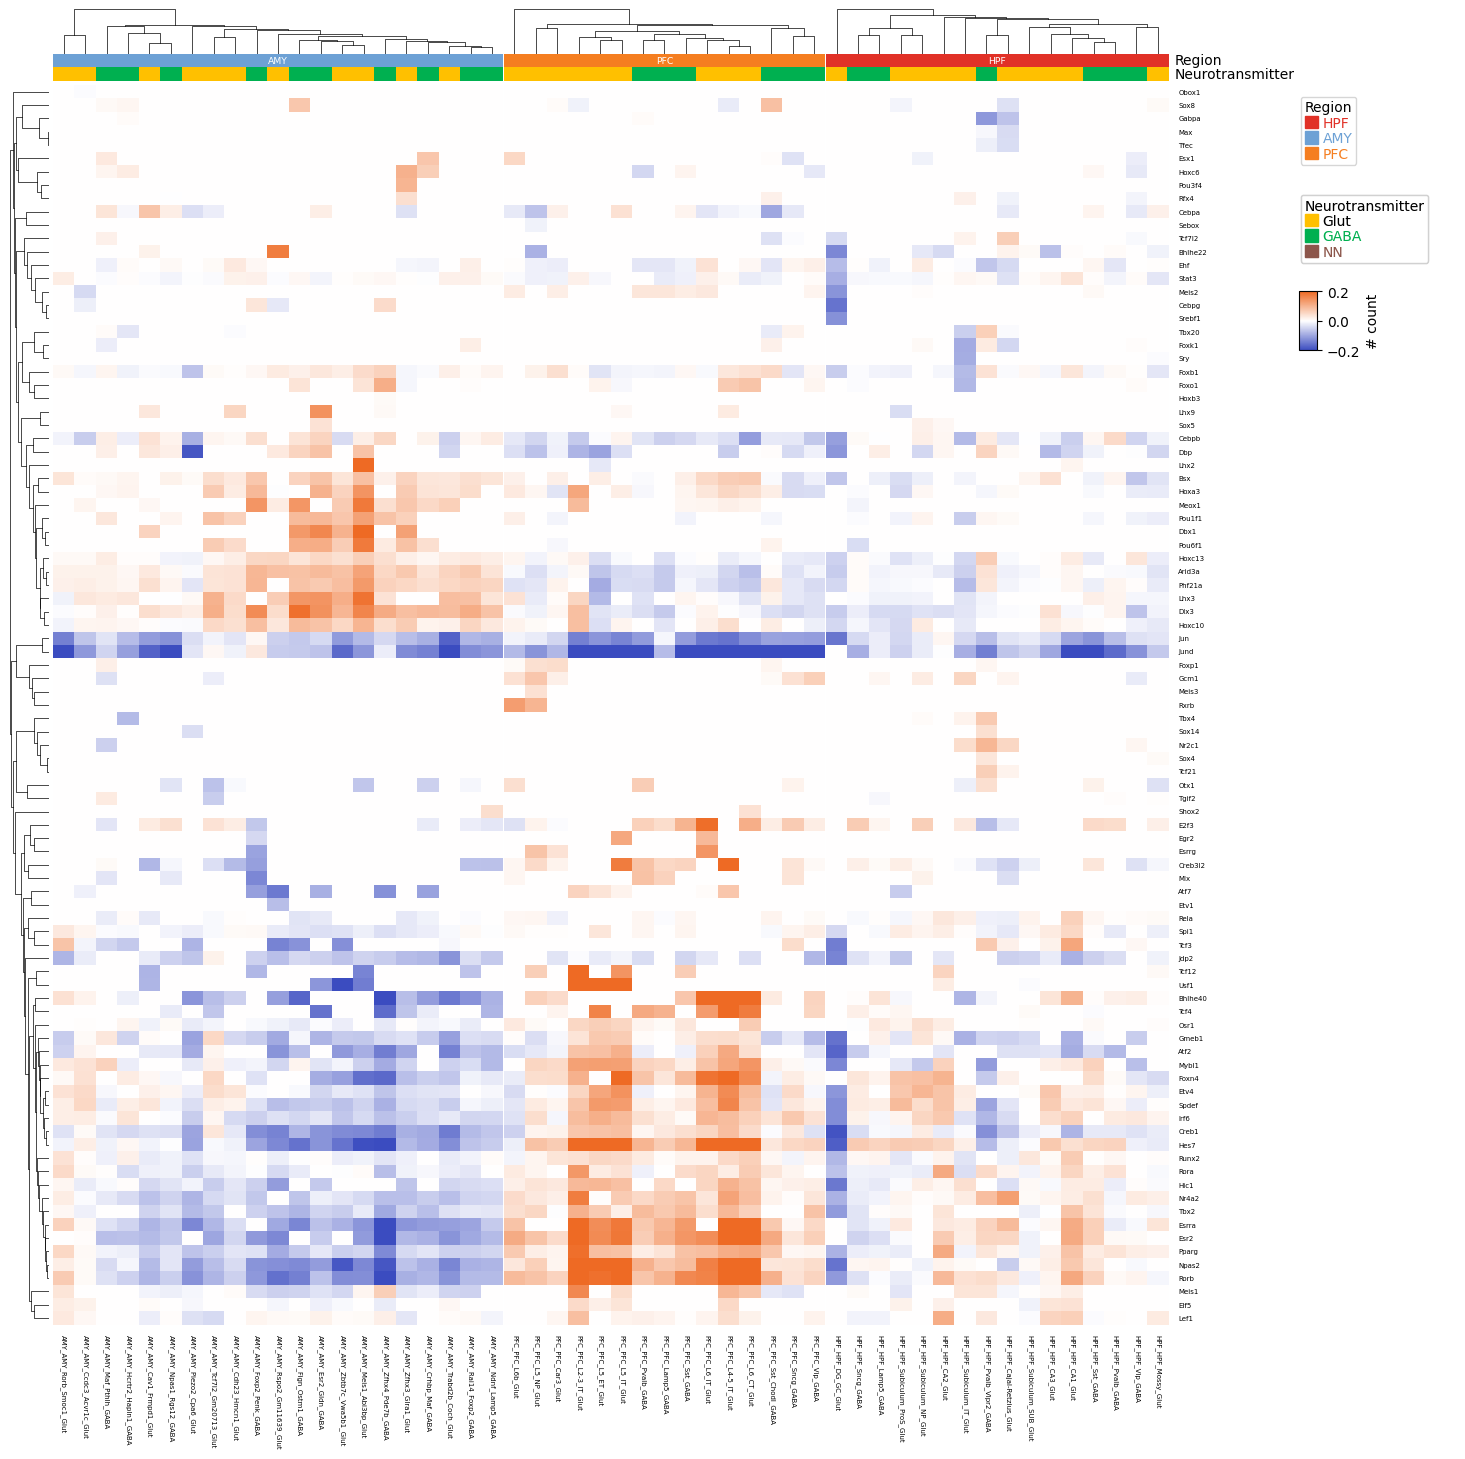

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


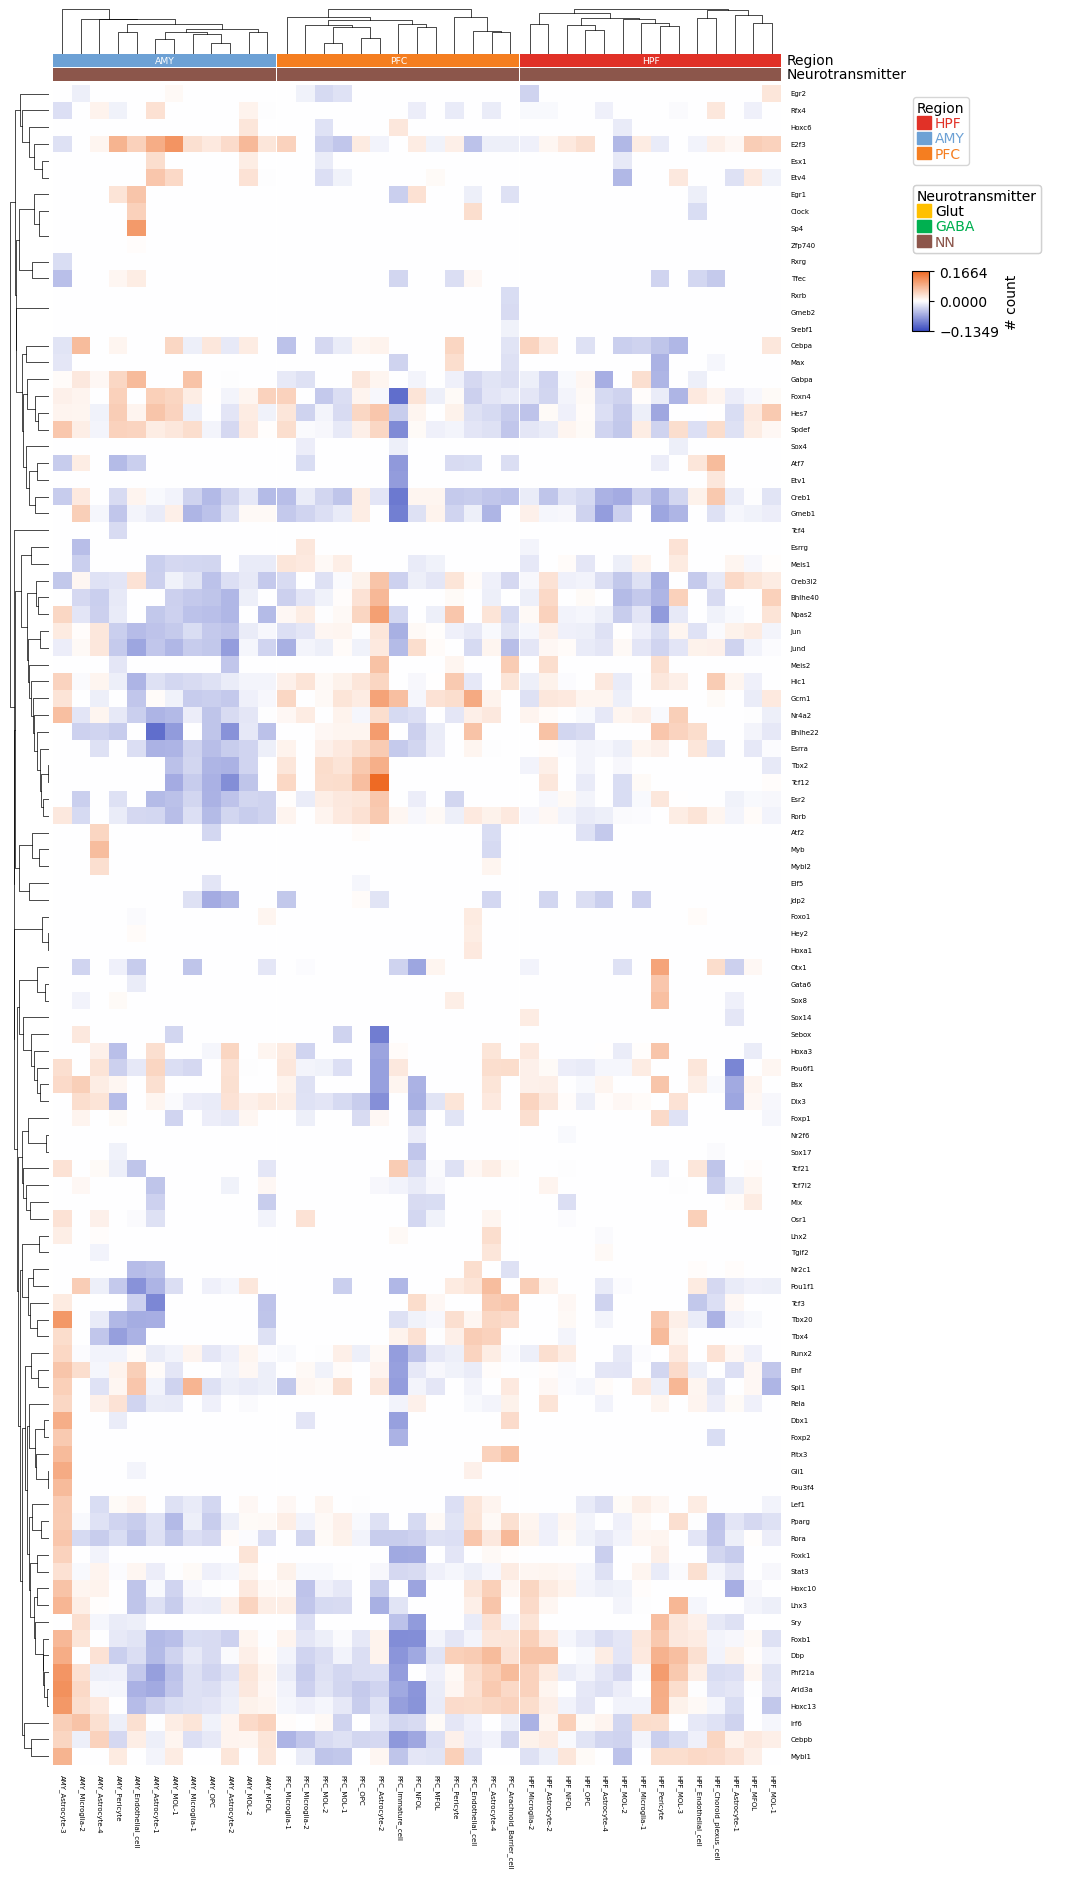

In [53]:

# 修改了 my_module.py 后，重新加载
importlib.reload(utils)

cm = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC",figure_size=(15,15)
                     , clipping=0.2,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_sub_{data_test}.pdf')
cmNN = draw_tf_heatmap(results[results.Neurotransmitter=='NN'],value_col="log2FC", clipping=100,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_NN_sub_{data_test}.pdf')
# cmavg = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter!='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_N_avg.pdf')
# cmavgNN = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter=='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_NN_avg.pdf')
row_names = list(cm.row_order)[0]
col_names = list(cm.col_order)
mat=cm.data2d.loc[row_names]
mat.to_csv(f'/data2st1/junyi/output/atac1112/tobias/BIND)sub_mat_{data_test}.csv')
# matavg = cmavg.data2d.loc[list(cmavg.row_order)[0]]
# matavg.to_csv('/data2st1/junyi/output/atac1112/tobias/BIND_matavg.csv')
# denrow = cm.dendrogram_row
# cm.dendrogram_row.dendrogram.keys()
# n = len(cm.dendrogram_row.dendrogram["leaves"])
# k = 10
# labels = np.repeat(np.arange(k), n//k + 1)[:n]

In [54]:
results

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Neurotransmitter,Region Subclass,FDR,Subclass,Region,status,celltype.L2,nlogp,Regulation,name_tf
0,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,42058,0.14791,8874,0.16927,10695,-0.41308,...,Glut,PFC_PFC_L4-5_IT_Glut,5.641080e-193,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,-192.248638,-1.0,Jund_metacluster_137.2cisbp__M01001_None
1,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,49246,0.15978,15728,0.17790,17378,-0.36419,...,Glut,PFC_PFC_L2-3_IT_Glut,2.094710e-188,PFC_L2-3_IT_Glut,PFC,Down,PFC_L2-3_IT_Glut,-187.678876,-1.0,Jund_metacluster_137.2cisbp__M01001_None
2,metacluster_14.17cisbp__M02818_None,metacluster_14.17#cisbp__M02818,None,C_metacluster_128.2#cisbp__M01721,14984,0.23914,3972,0.20986,3605,0.34449,...,Glut,PFC_PFC_L4-5_IT_Glut,5.805490e-160,PFC_L4-5_IT_Glut,PFC,Up,PFC_L4-5_IT_Glut,159.236161,1.0,Bhlhe40_metacluster_14.17cisbp__M02818_None
3,metacluster_121.1cisbp__M00820_None,metacluster_121.1#cisbp__M00820,None,C_metacluster_121.1#cisbp__M00820,33482,0.09209,5288,0.08048,4659,0.33697,...,Glut,PFC_PFC_L2-3_IT_Glut,3.463140e-177,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,176.460530,1.0,Rorb_metacluster_121.1cisbp__M00820_None
4,metacluster_121.1cisbp__M01297_None,metacluster_121.1#cisbp__M01297,None,C_metacluster_121.1#cisbp__M01297,34228,0.07565,4394,0.06548,3941,0.33097,...,Glut,PFC_PFC_L2-3_IT_Glut,1.863860e-179,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,178.729587,1.0,Esr2_metacluster_121.1cisbp__M01297_None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4261,metacluster_42.4transfac_public__M00510_None,metacluster_42.4#transfac_public__M00510,None,C_metacluster_42.4#transfac_public__M00510,18803,0.21365,2856,0.21721,2771,-0.00040,...,GABA,AMY_AMY_Npas1_Rgs12_GABA,3.902330e-03,AMY_Npas1_Rgs12_GABA,AMY,Down,AMY_Npas1_Rgs12_GABA,-2.408676,-1.0,Lhx3_metacluster_42.4transfac_public__M00510_None
4262,metacluster_118.1cisbp__M00545_None,metacluster_118.1#cisbp__M00545,None,C_metacluster_118.1#cisbp__M00545,18297,0.16651,8958,0.16630,9219,0.00014,...,NN,AMY_OPC,4.554010e-02,OPC,AMY,Up,OPC,1.341606,1.0,Pou6f1_metacluster_118.1cisbp__M00545_None
4263,metacluster_67.2cisbp__M00153_None,metacluster_67.2#cisbp__M00153,None,C_metacluster_67.2#cisbp__M00154,1316,5.15344,175,7.84705,289,-0.00012,...,NN,HPF_MOL-3,2.893230e-02,MOL-3,HPF,Down,MOL-3,-1.538617,-1.0,E2f3_metacluster_67.2cisbp__M00153_None
4264,metacluster_19.7cisbp__M00190_None,metacluster_19.7#cisbp__M00190,None,C_metacluster_19.7#cisbp__M00190,2055,1.12685,987,1.16055,1014,0.00007,...,GABA,HPF_HPF_Sncg_GABA,3.465330e-02,HPF_Sncg_GABA,HPF,Up,HPF_Sncg_GABA,1.460255,1.0,Gmeb1_metacluster_19.7cisbp__M00190_None


In [56]:
full_selected = results[results.FDR < 0.05]
full_selected['absLog2FC'] = full_selected['log2FC'].abs()
full_selected.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
full_selected.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)

In [57]:
full_selected.sort_values(by=['abs_change','total_tfbs'], ascending=[False,False], inplace=True)
full_selected
full_selected.drop_duplicates(subset=['Region Subclass','cluster'])

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Region Subclass,FDR,Subclass,Region,status,celltype.L2,nlogp,Regulation,name_tf,absLog2FC
0,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,42058,0.14791,8874,0.16927,10695,-0.41308,...,PFC_PFC_L4-5_IT_Glut,5.641080e-193,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,-192.248638,-1.0,Jund_metacluster_137.2cisbp__M01001_None,0.41308
1,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,49246,0.15978,15728,0.17790,17378,-0.36419,...,PFC_PFC_L2-3_IT_Glut,2.094710e-188,PFC_L2-3_IT_Glut,PFC,Down,PFC_L2-3_IT_Glut,-187.678876,-1.0,Jund_metacluster_137.2cisbp__M01001_None,0.36419
2,metacluster_14.17cisbp__M02818_None,metacluster_14.17#cisbp__M02818,None,C_metacluster_128.2#cisbp__M01721,14984,0.23914,3972,0.20986,3605,0.34449,...,PFC_PFC_L4-5_IT_Glut,5.805490e-160,PFC_L4-5_IT_Glut,PFC,Up,PFC_L4-5_IT_Glut,159.236161,1.0,Bhlhe40_metacluster_14.17cisbp__M02818_None,0.34449
3,metacluster_121.1cisbp__M00820_None,metacluster_121.1#cisbp__M00820,None,C_metacluster_121.1#cisbp__M00820,33482,0.09209,5288,0.08048,4659,0.33697,...,PFC_PFC_L2-3_IT_Glut,3.463140e-177,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,176.460530,1.0,Rorb_metacluster_121.1cisbp__M00820_None,0.33697
4,metacluster_121.1cisbp__M01297_None,metacluster_121.1#cisbp__M01297,None,C_metacluster_121.1#cisbp__M01297,34228,0.07565,4394,0.06548,3941,0.33097,...,PFC_PFC_L2-3_IT_Glut,1.863860e-179,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,178.729587,1.0,Esr2_metacluster_121.1cisbp__M01297_None,0.33097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4261,metacluster_42.4transfac_public__M00510_None,metacluster_42.4#transfac_public__M00510,None,C_metacluster_42.4#transfac_public__M00510,18803,0.21365,2856,0.21721,2771,-0.00040,...,AMY_AMY_Npas1_Rgs12_GABA,3.902330e-03,AMY_Npas1_Rgs12_GABA,AMY,Down,AMY_Npas1_Rgs12_GABA,-2.408676,-1.0,Lhx3_metacluster_42.4transfac_public__M00510_None,0.00040
4262,metacluster_118.1cisbp__M00545_None,metacluster_118.1#cisbp__M00545,None,C_metacluster_118.1#cisbp__M00545,18297,0.16651,8958,0.16630,9219,0.00014,...,AMY_OPC,4.554010e-02,OPC,AMY,Up,OPC,1.341606,1.0,Pou6f1_metacluster_118.1cisbp__M00545_None,0.00014
4263,metacluster_67.2cisbp__M00153_None,metacluster_67.2#cisbp__M00153,None,C_metacluster_67.2#cisbp__M00154,1316,5.15344,175,7.84705,289,-0.00012,...,HPF_MOL-3,2.893230e-02,MOL-3,HPF,Down,MOL-3,-1.538617,-1.0,E2f3_metacluster_67.2cisbp__M00153_None,0.00012
4264,metacluster_19.7cisbp__M00190_None,metacluster_19.7#cisbp__M00190,None,C_metacluster_19.7#cisbp__M00190,2055,1.12685,987,1.16055,1014,0.00007,...,HPF_HPF_Sncg_GABA,3.465330e-02,HPF_Sncg_GABA,HPF,Up,HPF_Sncg_GABA,1.460255,1.0,Gmeb1_metacluster_19.7cisbp__M00190_None,0.00007


In [58]:
full_selected['meta_cluster'] = full_selected['Region Subclass'].str.split('_').str[0]

In [59]:
full_selected.to_csv('/data2st1/junyi/output/atac1112/tobias/motif_filtererd.csv')

In [60]:
full_selected

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,FDR,Subclass,Region,status,celltype.L2,nlogp,Regulation,name_tf,absLog2FC,meta_cluster
0,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,42058,0.14791,8874,0.16927,10695,-0.41308,...,5.641080e-193,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,-192.248638,-1.0,Jund_metacluster_137.2cisbp__M01001_None,0.41308,PFC
1,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,49246,0.15978,15728,0.17790,17378,-0.36419,...,2.094710e-188,PFC_L2-3_IT_Glut,PFC,Down,PFC_L2-3_IT_Glut,-187.678876,-1.0,Jund_metacluster_137.2cisbp__M01001_None,0.36419,PFC
2,metacluster_14.17cisbp__M02818_None,metacluster_14.17#cisbp__M02818,None,C_metacluster_128.2#cisbp__M01721,14984,0.23914,3972,0.20986,3605,0.34449,...,5.805490e-160,PFC_L4-5_IT_Glut,PFC,Up,PFC_L4-5_IT_Glut,159.236161,1.0,Bhlhe40_metacluster_14.17cisbp__M02818_None,0.34449,PFC
3,metacluster_121.1cisbp__M00820_None,metacluster_121.1#cisbp__M00820,None,C_metacluster_121.1#cisbp__M00820,33482,0.09209,5288,0.08048,4659,0.33697,...,3.463140e-177,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,176.460530,1.0,Rorb_metacluster_121.1cisbp__M00820_None,0.33697,PFC
4,metacluster_121.1cisbp__M01297_None,metacluster_121.1#cisbp__M01297,None,C_metacluster_121.1#cisbp__M01297,34228,0.07565,4394,0.06548,3941,0.33097,...,1.863860e-179,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,178.729587,1.0,Esr2_metacluster_121.1cisbp__M01297_None,0.33097,PFC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4261,metacluster_42.4transfac_public__M00510_None,metacluster_42.4#transfac_public__M00510,None,C_metacluster_42.4#transfac_public__M00510,18803,0.21365,2856,0.21721,2771,-0.00040,...,3.902330e-03,AMY_Npas1_Rgs12_GABA,AMY,Down,AMY_Npas1_Rgs12_GABA,-2.408676,-1.0,Lhx3_metacluster_42.4transfac_public__M00510_None,0.00040,AMY
4262,metacluster_118.1cisbp__M00545_None,metacluster_118.1#cisbp__M00545,None,C_metacluster_118.1#cisbp__M00545,18297,0.16651,8958,0.16630,9219,0.00014,...,4.554010e-02,OPC,AMY,Up,OPC,1.341606,1.0,Pou6f1_metacluster_118.1cisbp__M00545_None,0.00014,AMY
4263,metacluster_67.2cisbp__M00153_None,metacluster_67.2#cisbp__M00153,None,C_metacluster_67.2#cisbp__M00154,1316,5.15344,175,7.84705,289,-0.00012,...,2.893230e-02,MOL-3,HPF,Down,MOL-3,-1.538617,-1.0,E2f3_metacluster_67.2cisbp__M00153_None,0.00012,HPF
4264,metacluster_19.7cisbp__M00190_None,metacluster_19.7#cisbp__M00190,None,C_metacluster_19.7#cisbp__M00190,2055,1.12685,987,1.16055,1014,0.00007,...,3.465330e-02,HPF_Sncg_GABA,HPF,Up,HPF_Sncg_GABA,1.460255,1.0,Gmeb1_metacluster_19.7cisbp__M00190_None,0.00007,HPF


# Region level analysis

In [77]:
if os.path.exists('/data2st1/junyi/output/atac1112/tobias/annotated_filtered_with_enhancers.parquet'):
    df_regions = pd.read_parquet('/data2st1/junyi/output/atac1112/tobias/annotated_filtered_with_enhancers.parquet')
    df_merged_region = df_regions
else:
    df_regions = pd.DataFrame()
    valid_files = []
    unvalid_files = []
    for idx, row in full_selected.iterrows():
        prefix = row['output_prefix']
        region = row['Region'].replace('HPF','HIP')
        subclass = row['Subclass']
        upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}cisbp_BIND/{region}_{subclass}_MC_footprints.bw/{prefix}/{prefix}_overview.txt'
        if os.path.exists(upbed):
            valid_files.append(upbed)
        else:
            unvalid_files.append(upbed)
        # if os.path.exists(downbed):
        #     valid_files.append(downbed)
        # else:
        #     unvalid_files.append(downbed)
    len(valid_files)
    df = dd.read_csv(valid_files, sep='\t', header=0,include_path_column="source_file")
    #df.columns = ['chr','start','end','name','score','strand','peak_chr','peak_start','peak_end','bound','source_file']
    df_filtered = df[(df['MC_bound']>0) | (df['MW_bound']>0)]
    df_filtered['absLog2FC']  = df_filtered['MC_MW_log2fc'].abs()
    df_filtered['Region Subclass'] = df_filtered['source_file'].str.split('/').str[7].str[:-17]
    df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HIP','HPF')
    df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HPF_HPF','HPF')
    df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('AMY_AMY','AMY')
    df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('PFC_PFC','PFC')
    df_filtered['names'] = df_filtered['peak_chr'].astype(str)+':'+df_filtered['peak_start'].astype(str)+'-'+df_filtered['peak_end'].astype(str)
    df_filtered['Direction'] = df_filtered['MC_MW_log2fc'].apply(lambda x: 'Up' if x > 0 else 'Down')
    df_regions= df_filtered.compute()
    dict_tfbs2tf = dict(zip(df_direct_annot['TFBS_name'], df_direct_annot['TF']))
    df_regions['TF'] = df_regions['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)
    df_annoated = pd.read_csv('/data2st1/junyi/output/atac1112/cCRE/cCRE_annotated.csv')
    df_merged_region = pd.merge(df_regions_f,df_annoated,how='inner',on='names')
    df_merged_region.to_parquet('/data2st1/junyi/output/atac1112/tobias/annotated_filtered.parquet', engine='pyarrow')  # or engine='fastparquet'

    df_merged_region.head()

In [71]:
df_regions.head(1000)

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,secondary_region,encodeCCRE,Sex,Ensemble,Gene,promoter,coaccess,gene_short_name,pedistance,PEstatus
0,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,...,repeat,None,M,ENSMUSG00000051951.5,chr1:3309937-3310438,None,NaN,None,NaN,None
1,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.34861,-,chr1,3309937,3310438,0.36816,...,repeat,None,M,ENSMUSG00000051951.5,chr1:3309937-3310438,None,NaN,None,NaN,None
2,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.26355,-,chr1,3309937,3310438,0.46053,...,repeat,None,M,ENSMUSG00000051951.5,chr1:3309937-3310438,None,NaN,None,NaN,None
3,chr1,3310134,3310143,metacluster_68.2cisbp__M00407_None,7.61715,+,chr1,3309937,3310438,0.20840,...,repeat,None,M,ENSMUSG00000051951.5,chr1:3309937-3310438,None,NaN,None,NaN,None
4,chr1,3309944,3309955,metacluster_137.2transfac_public__M00173_None,7.82886,-,chr1,3309937,3310438,0.11586,...,repeat,None,M,ENSMUSG00000051951.5,chr1:3309937-3310438,None,NaN,None,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,chr1,13660183,13660192,metacluster_137.2cisbp__M01001_None,8.16546,-,chr1,13659696,13660197,0.26263,...,SINE,"PLS,CTCF-bound",M,ENSMUSG00000025937.6,chr1:13659696-13660197,None,NaN,None,NaN,None
996,chr1,13660183,13660192,metacluster_137.2cisbp__M01001_None,8.18552,-,chr1,13659696,13660197,0.20314,...,SINE,"pELS,CTCF-bound",M,ENSMUSG00000025937.6,chr1:13659696-13660197,None,NaN,None,NaN,None
997,chr1,13660183,13660192,metacluster_137.2cisbp__M01001_None,8.18552,-,chr1,13659696,13660197,0.20314,...,SINE,"PLS,CTCF-bound",M,ENSMUSG00000025937.6,chr1:13659696-13660197,None,NaN,None,NaN,None
998,chr1,13660183,13660192,metacluster_137.2cisbp__M01001_None,8.19918,-,chr1,13659696,13660197,0.20837,...,SINE,"pELS,CTCF-bound",M,ENSMUSG00000025937.6,chr1:13659696-13660197,None,NaN,None,NaN,None


In [72]:
df_regions_f = df_regions#[df_regions['absLog2FC'] >= 0.1]
# df_regions_f['TF'] = df_regions_f['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

In [73]:
df_regions_f.shape

(15952749, 41)

In [74]:
df_deg = pd.read_csv("/data2st1/junyi/output/atac1112/dar/celltype.L2/mast_ngsa_noco_degs_fdr_log2fc0_filtered.csv")
df_deg['Region Subclass'] = df_deg['Region subclass'].str.replace(" ",'_')
df_deg['Region Subclass'] = df_deg['Region Subclass'].str.replace("/",'-')
df_deg = df_deg[df_deg.Sex=='M']
df_deg = df_deg[df_deg.Region.isin(['HPF','PFC','AMY'])]

In [ ]:
# for TF in df_test_TF_gene['TF'].unique():
#     df_tf = df_test_TF_gene[df_test_TF_gene['TF'] == TF]
#     concordant = sum(df_tf['Direction_deg'] == df_tf['Direction_tobias'])
#     total = df_tf.shape[0]
#     concordance_rate = concordant / total
#     print(f'TF: {TF}, Concordance Rate: {concordance_rate:.2f} ({concordant}/{total})')

In [78]:
def archr_distance_weight(d):
    d = abs(d)
    return np.exp(-d/5000) + np.exp(-1)

def copute_weighted_score(df_input):
    df_input['distance_weight'] = df_input['distance'].apply(archr_distance_weight)
    df_input["MC_Weighted"] = df_input["MC_score"] * df_input["distance_weight"]
    df_input["MW_Weighted"] = df_input["MW_score"] * df_input["distance_weight"]
    df_trimed = df_input[(df_input.distance <= 100000) & (df_input.distance >= -100000)]
    df_trimed_grouped =  df_trimed.groupby(['gene_name','Region Subclass']).sum().reset_index()
    df_trimed_grouped['log2FC'] = np.log2((df_trimed_grouped['MC_Weighted'] + 1e-10) / (df_trimed_grouped['MW_Weighted'] + 1e-10))
    df_trimed_grouped['Region subclass'] = df_trimed_grouped['Region Subclass']
    #Direction	Region	Neurotransmitter	Sex	Gene	Subclass
    df_trimed_grouped['Direction'] = df_trimed_grouped['log2FC'].apply(lambda x: 'Up' if x > 0 else 'Down')
    df_trimed_grouped['Sex'] = 'M'
    df_trimed_grouped['Gene'] = df_trimed_grouped['gene_name']
    df_trimed_grouped['Neurotransmitter'] = df_trimed_grouped['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    df_trimed_grouped['Subclass'] = df_trimed_grouped['Region Subclass']
    df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'] = df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'].str[4:]
    df_trimed_grouped['Region'] = df_trimed_grouped['Region Subclass'].str[:3].str.replace('HIP','HPF')
    return df_trimed_grouped

In [79]:
from matplotlib_venn import venn2
def draw_venndiagram(df1, df2,savepath=None,showplot=False,set_labels=("Tobias", "deg")):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2['Gene']+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = set_labels)
    if showplot:
        plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

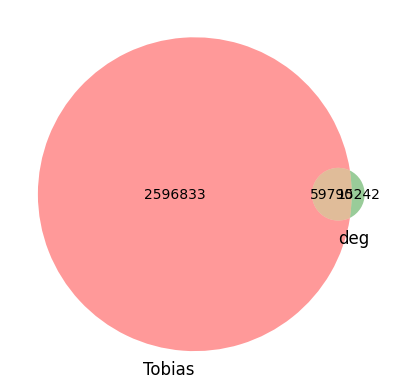

({'Gm4785_Up_PFC_L4-5_IT_Glut',
  'Pldi_Up_AMY_Meis1_Abi3bp_Glut',
  'Elf4_Up_HPF_NFOL',
  '4930537H20Rik_Up_HPF_Subiculum_ProS_Glut',
  'Fer1l6_Up_HPF_Microglia-2',
  'Gm48449_Up_AMY_Rorb_Smoc1_Glut',
  'Btbd8_Down_HPF_Cajal-Retzius_Glut',
  'Rpl7a-ps8_Up_AMY_MOL-1',
  'Orc2_Up_HPF_OPC',
  'Wasf2_Down_AMY_Ndnf_Lamp5_GABA',
  'Zfp341_Down_AMY_Cdh23_Hmcn1_Glut',
  '4933435F18Rik_Up_AMY_Rai14_Foxp2_GABA',
  'Mogs_Down_AMY_Astrocyte-4',
  'Gm48608_Up_PFC_L6_IT_Glut',
  'Mfsd4a_Down_AMY_OPC',
  'Pigu_Up_AMY_Rspo2_Gm11639_Glut',
  'Pef1_Up_AMY_Rai14_Foxp2_GABA',
  'Coasy_Up_AMY_Trabd2b_Coch_Glut',
  'Zfand5_Up_HPF_Choroid_plexus_cell',
  'Rbis_Down_AMY_Astrocyte-1',
  'Wdr5_Up_PFC_OPC',
  '4930535G08Rik_Up_HPF_MOL-2',
  'Plpp1_Up_HPF_Astrocyte-2',
  'Prkab2_Up_PFC_MFOL',
  'Gm13518_Up_AMY_Trabd2b_Coch_Glut',
  'Puf60_Up_AMY_Meis1_Abi3bp_Glut',
  'Dolk_Up_HPF_CA1_Glut',
  'Dcc_Up_PFC_L6_IT_Glut',
  'Nfatc2ip_Down_AMY_Pericyte',
  'Gm3745_Down_AMY_Ccdc3_Acvr1c_Glut',
  'Cul4b_Down_HPF_Pvalb_G

In [173]:
draw_venndiagram(df_regions_f, df_deg,showplot=True)

In [80]:
IoUs= []
TFs = []
pctDEG = []
for TF in df_merged_region.TF.unique():
    df_TF_jun = df_merged_region[df_merged_region.TF==TF]
    df_TF_jun_wg = copute_weighted_score(df_TF_jun)
    set1,set2 = draw_venndiagram(df_TF_jun, df_deg,savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{TF}_fileter_tobias_deg.pdf')
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    iou = len(intersection) / len(union) if len(union) > 0 else 0
    IoUs.append(iou)
    TFs.append(TF)
    pctDEG.append(len(intersection)/len(set2) if len(set2)>0 else 0)

/tmp/ipykernel_3554842/3602613066.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_input['distance_weight'] = df_input['distance'].apply(archr_distance_weight)
/tmp/ipykernel_3554842/3602613066.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_input["MC_Weighted"] = df_input["MC_score"] * df_input["distance_weight"]
/tmp/ipykernel_3554842/3602613066.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

In [81]:
df_results= pd.DataFrame({'TF':TFs, 'IoU':IoUs})

In [82]:
df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated_with_TFs.csv')
df_DAR['distance_weight'] = df_DAR['distance'].apply(archr_distance_weight)
df_DAR["log2FC_Weighted"] = df_DAR["log2FC"] * df_DAR["distance_weight"]


In [83]:
df_merged_region['Region'] = df_merged_region['Region Subclass'].str[:3].str.replace('HIP','HPF')

In [84]:
df_DAR['TFs'] = df_DAR['TFs'].str.split('/')

In [85]:
df_DAR_expanded = df_DAR.explode('TFs').reset_index(drop=True)

In [202]:
from matplotlib import cm
def show_stacked_barplot(df_DAR,column_status="primary_region",direction_col="Direction",title='',save=False):
    df = df_DAR.copy()
    # Aggregate
    up_df = df[df[direction_col] == "Up"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)
    down_df = df[df[direction_col] == "Down"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)

    # Down values become negative
    down_df = -down_df

    # Unified color palette for primary regions
    categories = up_df.columns
    cmap = cm.get_cmap("tab10", len(categories))  # or "Set3", "tab10", etc.
    colors = {cat: cmap(i) for i, cat in enumerate(categories)}


    plt.figure(figsize=(18,8))

    # ----- Plot Up (positive) -----
    bottom_up = None
    for region in up_df.columns:
        plt.bar(
            up_df.index,
            up_df[region],
            bottom=bottom_up,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3,
            label=region if bottom_up is None else ""
        )
        bottom_up = up_df[region] if bottom_up is None else bottom_up + up_df[region]

    # ----- Plot Down (negative) -----
    bottom_down = None
    for region in down_df.columns:
        plt.bar(
            down_df.index,
            down_df[region],
            bottom=bottom_down,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3
        )
        bottom_down = down_df[region] if bottom_down is None else bottom_down + down_df[region]

    # Formatting
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=90)
    plt.ylabel("Count")
    plt.title(title)

    # SINGLE legend (only regions)
    handles = [plt.Rectangle((0,0),1,1,color=colors[r]) for r in up_df.columns]
    plt.legend(handles, up_df.columns, bbox_to_anchor=(1.02,1), loc='upper left', title="Primary Region")

    plt.tight_layout()
    if save:
        plt.savefig(save,dpi=300)
    else:
        plt.show()


In [87]:
df_DAR_expanded['absLog2FC'] = df_DAR_expanded['log2FC_Weighted'].abs()
df_DAR_expanded.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
df_DAR_expanded.drop_duplicates(subset=['TFs','Region Subclass','names','status'],inplace=True)

In [88]:
df_DAR_expanded['TF']= df_DAR_expanded['TFs']

In [89]:
df_DAR['Gene'] = df_DAR['gene_name']

In [90]:
df_DAR

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Direction,Neurotransmitter,Gene_name,FDR,Region Subclass Direction,TFs,motifs,method,distance_weight,log2FC_Weighted
0,chr10:100456562-100457063,1.414898e-02,-0.006031,0.006165,-0.018226,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.751694e-02,...,Down,Glut,chr10:100456562-100457063,2.751694e-02,HPF_CA3_Glut_Down,NaN,NaN,NaN,1.367879,-0.008249
1,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,Up,Glut,chr10:100487209-100487710,9.867574e-08,HPF_CA3_Glut_Up,"[2610021A01Rik, Cnot3, Creb1, E2f1, E2f3, E2f4...",hdpi__ELF2/dbtfbs__E2F8_representative_N1/meta...,MASTNG,1.367879,0.093303
2,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,Up,Glut,chr10:100487209-100487710,9.867574e-08,HPF_CA3_Glut_Up,"[2610021A01Rik, Cnot3, Creb1, E2f1, E2f3, E2f4...",hdpi__ELF2/dbtfbs__E2F8_representative_N1/meta...,MASTNG,1.367879,0.093303
3,chr10:100642797-100643298,6.163128e-03,-0.014478,-0.004093,-0.024864,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,1.490774e-02,...,Down,Glut,chr10:100642797-100643298,1.490774e-02,HPF_CA3_Glut_Down,"[2610021A01Rik, Gm28168, Gm28360, Gm7145, Kat7...",metacluster_151.1,MASTNG,0.556805,-0.008062
4,chr10:10107158-10107659,5.303556e-07,0.030881,0.045954,0.015808,0.017210,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.347109e-05,...,Up,Glut,chr10:10107158-10107659,2.347109e-05,HPF_CA3_Glut_Up,"[En1, Spdef]",metacluster_191.5/transfac_public__M00396,MASTNG,1.367879,0.042241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334132,chr7:99535252-99535753,4.700413e-06,0.001785,0.060391,-0.056820,0.079099,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,1.977464e-02,...,Up,GABA,chr7:99535252-99535753,1.977464e-02,AMY_Npas1_Rgs12_GABA_Up,"[Ahr, Arnt, E2f2, E2f3, E2f6, Egr1, Elf2, Elf3...",hdpi__NRL/swissregulon__hs__AHR/transfac_pro__...,MASTNG,1.367879,0.002442
334133,chr9:103365644-103366145,8.286317e-05,0.028069,0.108636,-0.052498,1.000000,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,4.904168e-02,...,Up,GABA,chr9:103365644-103366145,4.904168e-02,AMY_Npas1_Rgs12_GABA_Up,NaN,NaN,NaN,1.367879,0.038395
334134,chr9:99436435-99436936,3.917479e-05,-0.054067,-0.014330,-0.093805,0.659233,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,3.488255e-02,...,Down,GABA,chr9:99436435-99436936,3.488255e-02,AMY_Npas1_Rgs12_GABA_Down,"[Atf1, Atf2, Atf3, Atf4, Atf7, Creb1, Crem, Eh...",dbtfbs__E2F8_representative_N1/transfac_pro__M...,MASTNG,1.367879,-0.073957
334135,chr13:43171217-43171718,2.009124e-06,NaN,NaN,NaN,0.018430,PFC_Sst_Chodl_GABA,PFC,PFC_Sst_Chodl_GABA,1.842970e-02,...,Down,GABA,chr13:43171217-43171718,1.842970e-02,PFC_Sst_Chodl_GABA_Down,"[Atf2, E4f1, Elk1, Elk3, Elk4, Epas1, Erg, Ets...",taipale_tf_pairs__CLOCK_FIGLA_NCASSTGKNNNNNNNN...,MASTNG,1.367879,NaN


In [91]:
df_DAR['absLog2FC'] = df_DAR['log2FC'].abs()

In [92]:
df_DAR_expanded['Gene'] = df_DAR_expanded['gene_name']
df_merged_region['Gene'] = df_merged_region['gene_name']

In [93]:
df_DAR_expanded.head()

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Gene_name,FDR,Region Subclass Direction,TFs,motifs,method,distance_weight,log2FC_Weighted,absLog2FC,TF
6229204,chr6:103648953-103649454,1.910131e-05,1.466141,1.920083,1.012200,2.895758e-02,Ependymal_cell,HPF,HPF_Ependymal_cell,2.895758e-02,...,chr6:103648953-103649454,2.895758e-02,HPF_Ependymal_cell_Up,NaN,NaN,NaN,1.367879,2.005505,2.005505,NaN
8238955,chr2:98666919-98667420,1.786185e-24,1.034066,1.216309,0.851823,3.068666e-20,AMY_Tcf7l2_Gm20713_Glut,AMY,AMY_Tcf7l2_Gm20713_Glut,3.068666e-20,...,chr2:98666919-98667420,3.068666e-20,AMY_Tcf7l2_Gm20713_Glut_Up,NaN,NaN,NaN,1.367879,1.414478,1.414478,NaN
4745876,chr2:98666919-98667420,2.625773e-98,0.859369,0.935932,0.782806,4.145570e-94,AMY_Zfhx4_Pde7b_GABA,AMY,AMY_Zfhx4_Pde7b_GABA,4.145570e-94,...,chr2:98666919-98667420,4.145570e-94,AMY_Zfhx4_Pde7b_GABA_Up,NaN,NaN,NaN,1.367879,1.175513,1.175513,NaN
2086102,chr2:98666919-98667420,3.499952e-12,0.835068,1.076561,0.593574,5.464125e-08,MOL-2,AMY,AMY_MOL.2,5.464125e-08,...,chr2:98666919-98667420,5.464125e-08,AMY_MOL-2_Up,NaN,NaN,NaN,1.367879,1.142272,1.142272,NaN
4226553,chr2:98666919-98667420,4.452674e-30,0.726474,0.842969,0.609978,5.879756e-26,PFC_Vip_GABA,PFC,PFC_Vip_GABA,5.879756e-26,...,chr2:98666919-98667420,5.879756e-26,PFC_Vip_GABA_Up,NaN,NaN,NaN,1.367879,0.993729,0.993729,NaN


In [94]:
df_DAR['TF'] = df_DAR['TFs']

In [95]:
# PEARSON R
from scipy.stats import pearsonr, spearmanr
def summerize_correlation(df, col1, col2):
    corrs = {}
    pvales = {}
    for tf in df['TF'].unique():
        df_tf = df[df['TF'] == tf]
        corr_value = spearmanr(df_tf[col1], df_tf[col2])[0]
        corr_p = spearmanr(df_tf[col1], df_tf[col2])[1]
        corrs[tf] = corr_value
        pvales[tf] = corr_p
    return corrs, pvales

In [96]:
df_merged_region['tobias_log2FC'] = df_merged_region['MC_MW_log2fc']
df_DAR_expanded.rename(columns={'log2FC':'DAR_log2FC'}, inplace=True)

In [97]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,Sex,Ensemble,Gene,promoter,coaccess,gene_short_name,pedistance,PEstatus,Region,tobias_log2FC
0,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,...,M,ENSMUSG00000051951.5,Xkr4,None,NaN,None,NaN,None,PFC,-0.76929
1,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.34861,-,chr1,3309937,3310438,0.36816,...,M,ENSMUSG00000051951.5,Xkr4,None,NaN,None,NaN,None,HPF,-1.05601
2,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.26355,-,chr1,3309937,3310438,0.46053,...,M,ENSMUSG00000051951.5,Xkr4,None,NaN,None,NaN,None,AMY,0.51860
3,chr1,3310134,3310143,metacluster_68.2cisbp__M00407_None,7.61715,+,chr1,3309937,3310438,0.20840,...,M,ENSMUSG00000051951.5,Xkr4,None,NaN,None,NaN,None,PFC,-0.54081
4,chr1,3309944,3309955,metacluster_137.2transfac_public__M00173_None,7.82886,-,chr1,3309937,3310438,0.11586,...,M,ENSMUSG00000051951.5,Xkr4,None,NaN,None,NaN,None,PFC,-0.76929


In [103]:
df_merged_region.loc[df_merged_region['primary_region']=='promoter','PEstatus'] = 'promoter'
df_merged_region.loc[df_merged_region['PEstatus']=='promoter_proximal','PEstatus'] = 'promoter'

In [199]:
df_merged_region['promoter']=df_merged_region['promoter'].str.replace('_', ':', 1).str.replace('_', '-', 1)

In [201]:
df_grn_final

,Gene,Region Subclass,Direction,TF_gene
0,4732471J01Rik,PFC_Astrocyte-2,Up,Promoter
1,4732471J01Rik,PFC_Astrocyte-2,Up,Promoter
2,4732471J01Rik,PFC_Astrocyte-2,Up,Promoter
3,4833420G17Rik,PFC_Astrocyte-2,Up,Promoter
4,4833420G17Rik,PFC_Astrocyte-2,Up,Promoter
...,...,...,...,...
143324,Rbm26,AMY_OPC,Down,Enhancer
143325,Scg2,AMY_OPC,Down,Enhancer
143326,Scrg1,AMY_OPC,Up,Enhancer
143327,Unc5c,AMY_OPC,Down,Enhancer


In [205]:
result_dict = {}
exp, df_tmp_all = ("tobias", df_merged_region)

df_tmp_promoter = df_tmp_all[df_tmp_all['PEstatus']=='promoter']
df_tmp_promoter.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
#df_unq = df_tmp_promoter.drop_duplicates(subset=['gene_name','Region Subclass','TF','Direction'])
df_unq = df_tmp_promoter
df_deg_merge = pd.merge(df_unq, df_deg, how='right', left_on=['Region Subclass','Gene','Direction'], right_on=['Region Subclass','Gene','Direction'],
                    suffixes=('_promoter','_deg'),indicator='ispromoter')
#df_deg_merge_gene = df_deg_merge.drop_duplicates(subset=['Region Subclass','Gene','Direction'])
df_deg_merge_gene = df_deg_merge
df_deg_merge_promoter = df_deg_merge_gene[df_deg_merge_gene['ispromoter']=='both']


/tmp/ipykernel_3554842/3872306580.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp_promoter.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)


In [211]:
df_deg_merge_promoter

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,Bonferroni,Subclass,Region_deg,Sex_deg,Method,Ensemble_deg,Gene_name,Neurotransmitter,Region subclass,ispromoter
2,chr7,25395949.0,25395958.0,metacluster_149.1cisbp__M01740_None,7.64322,-,chr7,25395463.0,25395964.0,1.32117,...,1.00000,Astrocyte-2,PFC,M,MAST,ENSMUSG00000053714,"""4732471J01Rik""",NN,PFC Astrocyte-2,both
3,chr7,25395934.0,25395945.0,metacluster_137.2transfac_public__M00173_None,8.40966,-,chr7,25395463.0,25395964.0,1.12332,...,1.00000,Astrocyte-2,PFC,M,MAST,ENSMUSG00000053714,"""4732471J01Rik""",NN,PFC Astrocyte-2,both
4,chr7,25395784.0,25395794.0,metacluster_189.1cisbp__M00198_None,6.91654,+,chr7,25395463.0,25395964.0,3.48943,...,1.00000,Astrocyte-2,PFC,M,MAST,ENSMUSG00000053714,"""4732471J01Rik""",NN,PFC Astrocyte-2,both
5,chr13,119462746.0,119462756.0,metacluster_183.3cisbp__M00158_None,8.82942,-,chr13,119462463.0,119462964.0,1.63784,...,1.00000,Astrocyte-2,PFC,M,MAST,ENSMUSG00000062822,"""4833420G17Rik""",NN,PFC Astrocyte-2,both
6,chr13,119462746.0,119462756.0,metacluster_166.3cisbp__M00159_None,6.69259,-,chr13,119462463.0,119462964.0,1.63784,...,1.00000,Astrocyte-2,PFC,M,MAST,ENSMUSG00000062822,"""4833420G17Rik""",NN,PFC Astrocyte-2,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178118,chr4,121098180.0,121098193.0,metacluster_162.5transfac_public__M00157_None,6.69539,-,chr4,121097921.0,121098422.0,0.54527,...,1.00000,OPC,AMY,M,MAST,ENSMUSG00000043207,"""Zmpste24""",NN,AMY OPC,both
178119,chr3,157534602.0,157534611.0,metacluster_128.2cisbp__M00119_None,8.51405,+,chr3,157534408.0,157534909.0,0.51373,...,0.19476,OPC,AMY,M,MAST,ENSMUSG00000028180,"""Zranb2""",NN,AMY OPC,both
178120,chr13,107890841.0,107890850.0,metacluster_149.1cisbp__M01740_None,7.60406,-,chr13,107890767.0,107891268.0,0.48688,...,1.00000,OPC,AMY,M,MAST,ENSMUSG00000032846,"""Zswim6""",NN,AMY OPC,both
178121,chr13,107890101.0,107890111.0,metacluster_183.3cisbp__M01490_None,6.94062,+,chr13,107889931.0,107890432.0,4.19942,...,1.00000,OPC,AMY,M,MAST,ENSMUSG00000032846,"""Zswim6""",NN,AMY OPC,both


In [207]:


# df_deg_merge_nomap = df_deg_merge_promoter
# df_deg_merge_nomap = df_deg_merge_nomap.dropna(axis=1)
df_near_proximal = df_tmp_all[(df_tmp_all['PEstatus'].isin(['distal_enhancer','near_proximal_enhancer']))]
df_deg_merge_proxima = pd.merge(df_near_proximal, df_deg, how='right', left_on=['Region Subclass','Gene','Direction'], right_on=['Region Subclass','Gene','Direction'],
                    suffixes=('_prx','_degn'),indicator='nearproximal')



In [210]:
df_deg_merge_proxima[df_deg_merge_proxima.nearproximal=='both'].drop_duplicates()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,Bonferroni,Subclass,Region_degn,Sex_degn,Method,Ensemble_degn,Gene_name,Neurotransmitter,Region subclass,nearproximal
9,chr8,4166339.0,4166349.0,metacluster_158.5cisbp__M00830_None,6.59853,-,chr8,4165942.0,4166443.0,3.14839,...,1.000000,Astrocyte-2,PFC,M,MAST,ENSMUSG00000086805,"""4932443L11Rik""",NN,PFC Astrocyte-2,both
11,chr7,4111802.0,4111811.0,metacluster_18.3cisbp__M00141_None,7.13200,-,chr7,4111710.0,4112211.0,0.54397,...,0.022665,Astrocyte-2,PFC,M,MAST,ENSMUSG00000086155,"""9430041J12Rik""",NN,PFC Astrocyte-2,both
12,chr7,4111965.0,4111977.0,metacluster_111.4transfac_public__M00177_None,8.54093,-,chr7,4111710.0,4112211.0,1.32424,...,0.022665,Astrocyte-2,PFC,M,MAST,ENSMUSG00000086155,"""9430041J12Rik""",NN,PFC Astrocyte-2,both
13,chr7,4111967.0,4111977.0,metacluster_111.3cisbp__M01810_None,8.49049,-,chr7,4111710.0,4112211.0,1.32424,...,0.022665,Astrocyte-2,PFC,M,MAST,ENSMUSG00000086155,"""9430041J12Rik""",NN,PFC Astrocyte-2,both
14,chr7,4111838.0,4111848.0,metacluster_189.1cisbp__M00198_None,6.93760,+,chr7,4111710.0,4112211.0,0.61829,...,0.022665,Astrocyte-2,PFC,M,MAST,ENSMUSG00000086155,"""9430041J12Rik""",NN,PFC Astrocyte-2,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78662,chr3,141476776.0,141476785.0,metacluster_118.1cisbp__M00532_None,6.94133,-,chr3,141476527.0,141477028.0,0.47085,...,0.330799,OPC,AMY,M,MAST,ENSMUSG00000059921,"""Unc5c""",NN,AMY OPC,both
78663,chr3,141476861.0,141476870.0,metacluster_118.1cisbp__M00532_None,6.66613,-,chr3,141476527.0,141477028.0,0.37886,...,0.330799,OPC,AMY,M,MAST,ENSMUSG00000059921,"""Unc5c""",NN,AMY OPC,both
78664,chr3,141476777.0,141476785.0,metacluster_1.10cisbp__M00421_None,8.31562,-,chr3,141476527.0,141477028.0,0.47085,...,0.330799,OPC,AMY,M,MAST,ENSMUSG00000059921,"""Unc5c""",NN,AMY OPC,both
78671,chr7,40906952.0,40906961.0,metacluster_121.1cisbp__M01297_None,7.07159,+,chr7,40906461.0,40906962.0,0.10636,...,0.353346,OPC,AMY,M,MAST,ENSMUSG00000039257,"""Vstm2b""",NN,AMY OPC,both


In [212]:
df_deg_merge_proxima_unique = df_deg_merge_proxima.drop_duplicates()
df_deg_merge_proxima_unique['TF_gene'] = df_deg_merge_proxima_unique['nearproximal'].map({'both':'Enhancer','right_only':'Umapped'})
df_deg_merge_promoter['TF_gene'] = 'Promoter'

/tmp/ipykernel_3554842/2619711770.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_deg_merge_promoter['TF_gene'] = 'Promoter'


In [249]:
def show_stacked_barplot(df_DAR, column_status="primary_region", direction_col="Direction", 
                        title='', save=False, normalize=False, normalize_method="both", 
                        normalize_scale=1.0, separate_normalization=False,colormap=None):
    """
    绘制堆叠条形图，显示不同区域和方向（上调/下调）的计数
    
    参数:
    df_DAR: 包含DAR数据的DataFrame
    column_status: 用于分组的列名
    direction_col: 包含"Up"/"Down"方向的列名
    title: 图表标题
    save: 是否保存图表，False则显示，字符串则保存为文件名
    normalize: 是否归一化
    normalize_method: 归一化方法
        - "both": UP和DOWN一起归一化到相同总长度
        - "separate": UP和DOWN各自独立归一化
        - "up_only": 只归一化UP部分
        - "down_only": 只归一化DOWN部分
    normalize_scale: 归一化后的长度
    separate_normalization: 已弃用，请使用normalize_method
    """
    from matplotlib import cm
    df = df_DAR.copy()
    
    # 向后兼容：如果使用separate_normalization参数
    if separate_normalization:
        normalize_method = "separate"
        normalize = True
    
    # 聚合数据
    up_df = df[df[direction_col] == "Up"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)
    down_df = df[df[direction_col] == "Down"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)
    
    # 下调值变为负值
    down_df_original = down_df.copy()
    down_df = -down_df
    
    # 归一化处理
    if normalize:
        if normalize_method == "both":
            # 方法1: UP和DOWN一起归一化
            total_counts = up_df.abs().sum(axis=1) + down_df_original.abs().sum(axis=1)
            scale_factors = normalize_scale / total_counts
            up_df = up_df.multiply(scale_factors, axis=0)
            down_df = down_df.multiply(scale_factors, axis=0)
            
        elif normalize_method == "separate":
            # 方法2: UP和DOWN各自独立归一化
            # UP部分：归一化到normalize_scale/2
            up_total = up_df.sum(axis=1)
            up_scale_factors = (normalize_scale/2) / up_total
            up_df = up_df.multiply(up_scale_factors, axis=0)
            
            # DOWN部分：归一化到normalize_scale/2
            down_total = down_df_original.sum(axis=1)  # 使用绝对值
            down_scale_factors = (normalize_scale/2) / down_total
            down_df = down_df.multiply(down_scale_factors, axis=0)
            
        elif normalize_method == "up_only":
            # 方法3: 只归一化UP部分
            up_total = up_df.sum(axis=1)
            up_scale_factors = normalize_scale / up_total
            up_df = up_df.multiply(up_scale_factors, axis=0)
            # DOWN部分保持不变
            
        elif normalize_method == "down_only":
            # 方法4: 只归一化DOWN部分
            down_total = down_df_original.sum(axis=1)  # 使用绝对值
            down_scale_factors = normalize_scale / down_total
            down_df = down_df.multiply(down_scale_factors, axis=0)
            # UP部分保持不变
            
        else:
            raise ValueError(f"未知的归一化方法: {normalize_method}。可选: 'both', 'separate', 'up_only', 'down_only'")
    
    # 统一的颜色调色板
    categories = up_df.columns
    if colormap is None:
        cmap = cm.get_cmap("Set3", len(categories))
        colors = {cat: cmap(i) for i, cat in enumerate(categories)}
    elif isinstance(colormap, dict):
        colors = colormap
    elif isinstance(colormap, str):
        cmap = cm.get_cmap(colormap, len(categories))
        colors = {cat: cmap(i) for i, cat in enumerate(categories)}
        
    plt.figure(figsize=(18, 8))
    
    # ----- 绘制上调（正值）部分 -----
    bottom_up = None
    for region in up_df.columns:
        plt.bar(
            up_df.index,
            up_df[region],
            bottom=bottom_up,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3,
            label=region if bottom_up is None else ""
        )
        bottom_up = up_df[region] if bottom_up is None else bottom_up + up_df[region]
    
    # ----- 绘制下调（负值）部分 -----
    bottom_down = None
    for region in down_df.columns:
        plt.bar(
            down_df.index,
            down_df[region],
            bottom=bottom_down,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3
        )
        bottom_down = down_df[region] if bottom_down is None else bottom_down + down_df[region]
    
    # 格式设置
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=90)
    
    # 设置y轴标签和刻度
    if normalize:
        if normalize_method == "both":
            ylabel = f"Proportion (total normalized to {normalize_scale})"
            y_max = normalize_scale
        elif normalize_method == "separate":
            ylabel = f"Proportion (UP/DOWN each normalized to {normalize_scale/2})"
            y_max = normalize_scale/2
        elif normalize_method == "up_only":
            ylabel = f"Count / Proportion (UP normalized to {normalize_scale})"
            # 计算y轴最大范围
            y_max = max(normalize_scale, abs(down_df.sum(axis=1).min()))
        elif normalize_method == "down_only":
            ylabel = f"Count / Proportion (DOWN normalized to {normalize_scale})"
            # 计算y轴最大范围
            y_max = max(up_df.sum(axis=1).max(), normalize_scale)
    else:
        ylabel = "Count"
        # 计算y轴范围
        y_max = max(up_df.sum(axis=1).max(), abs(down_df.sum(axis=1).min()))
    
    plt.ylabel(ylabel)
    
    # 设置对称的y轴
    y_ticks = np.linspace(-y_max, y_max, 9)
    y_tick_labels = [f"{abs(y):.1f}" if y < 0 else f"{y:.1f}" for y in y_ticks]
    plt.yticks(y_ticks, y_tick_labels)
    plt.ylim(-y_max*1.1, y_max*1.1)  # 增加10%的边距
    
    # 添加标题
    if normalize:
        title_with_norm = f"{title} - {normalize_method} normalization"
    else:
        title_with_norm = title
    plt.title(title_with_norm)
    
    # 单个图例（仅显示区域）
    handles = [plt.Rectangle((0, 0), 1, 1, color=colors[r]) for r in up_df.columns]
    plt.legend(handles, up_df.columns, bbox_to_anchor=(1.02, 1), loc='upper left', title=column_status)
    
    # 在图表上添加归一化说明
    if normalize:
        if normalize_method == "separate":
            plt.figtext(0.02, 0.02, f"UP和DOWN各自独立归一化，长度各为{normalize_scale/2}", 
                       fontsize=9, style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
        elif normalize_method == "both":
            plt.figtext(0.02, 0.02, f"UP和DOWN一起归一化，总长度为{normalize_scale}", 
                       fontsize=9, style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
    
    plt.tight_layout()
    
    if save:
        plt.savefig(save, dpi=300, bbox_inches='tight')
    else:
        plt.show()
    
    # 返回处理后的数据用于进一步分析
    return {
        'up_df': up_df,
        'down_df': down_df,
        'normalize_method': normalize_method if normalize else None
    }

In [259]:
df_promoter_final = df_deg_merge_promoter[['Gene','Region Subclass','Direction','TF_gene']]
df_enhancer_final = df_deg_merge_proxima_unique[['Gene','Region Subclass','Direction','TF_gene']]
df_grn_final = pd.concat([df_promoter_final, df_enhancer_final], axis=0)
custom_order = ['Enhancer', 'Promoter', 'Umapped']

# 将TF_gene列转换为分类类型，并指定顺序
df_grn_final['TF_gene'] = pd.Categorical(
    df_grn_final['TF_gene'], 
    categories=custom_order, 
    ordered=True
)
df_grn_final.drop_duplicates(subset=['Region Subclass','Gene','Direction'], inplace=True)

/tmp/ipykernel_3554842/357604633.py:172: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from current font.
  plt.savefig(save, dpi=300, bbox_inches='tight')
/tmp/ipykernel_3554842/357604633.py:172: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from current font.
  plt.savefig(save, dpi=300, bbox_inches='tight')
/tmp/ipykernel_3554842/357604633.py:172: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from current font.
  plt.savefig(save, dpi=300, bbox_inches='tight')
/tmp/ipykernel_3554842/357604633.py:172: UserWarning: Glyph 29420 (\N{CJK UNIFIED IDEOGRAPH-72EC}) missing from current font.
  plt.savefig(save, dpi=300, bbox_inches='tight')
/tmp/ipykernel_3554842/357604633.py:172: UserWarning: Glyph 31435 (\N{CJK UNIFIED IDEOGRAPH-7ACB}) missing from current font.
  plt.savefig(save, dpi=300, bbox_inches='tight')
/tmp/ipykernel_3554842/357604633.py:172: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from current 

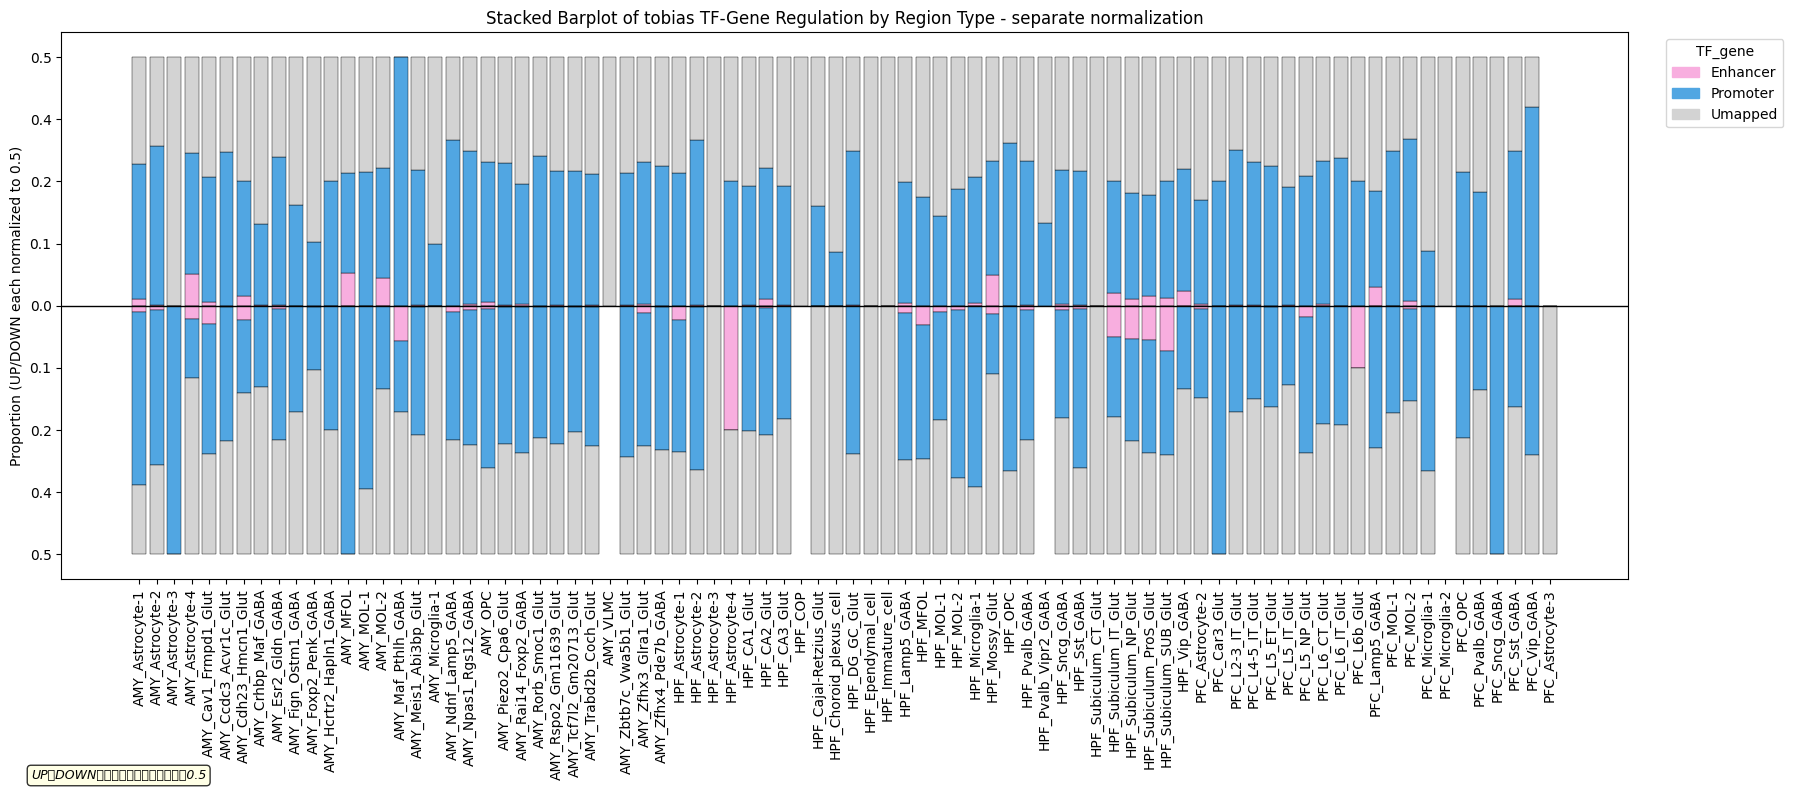

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36215 (\N{CJK UNIFIED IDEOGRAPH-8D77}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


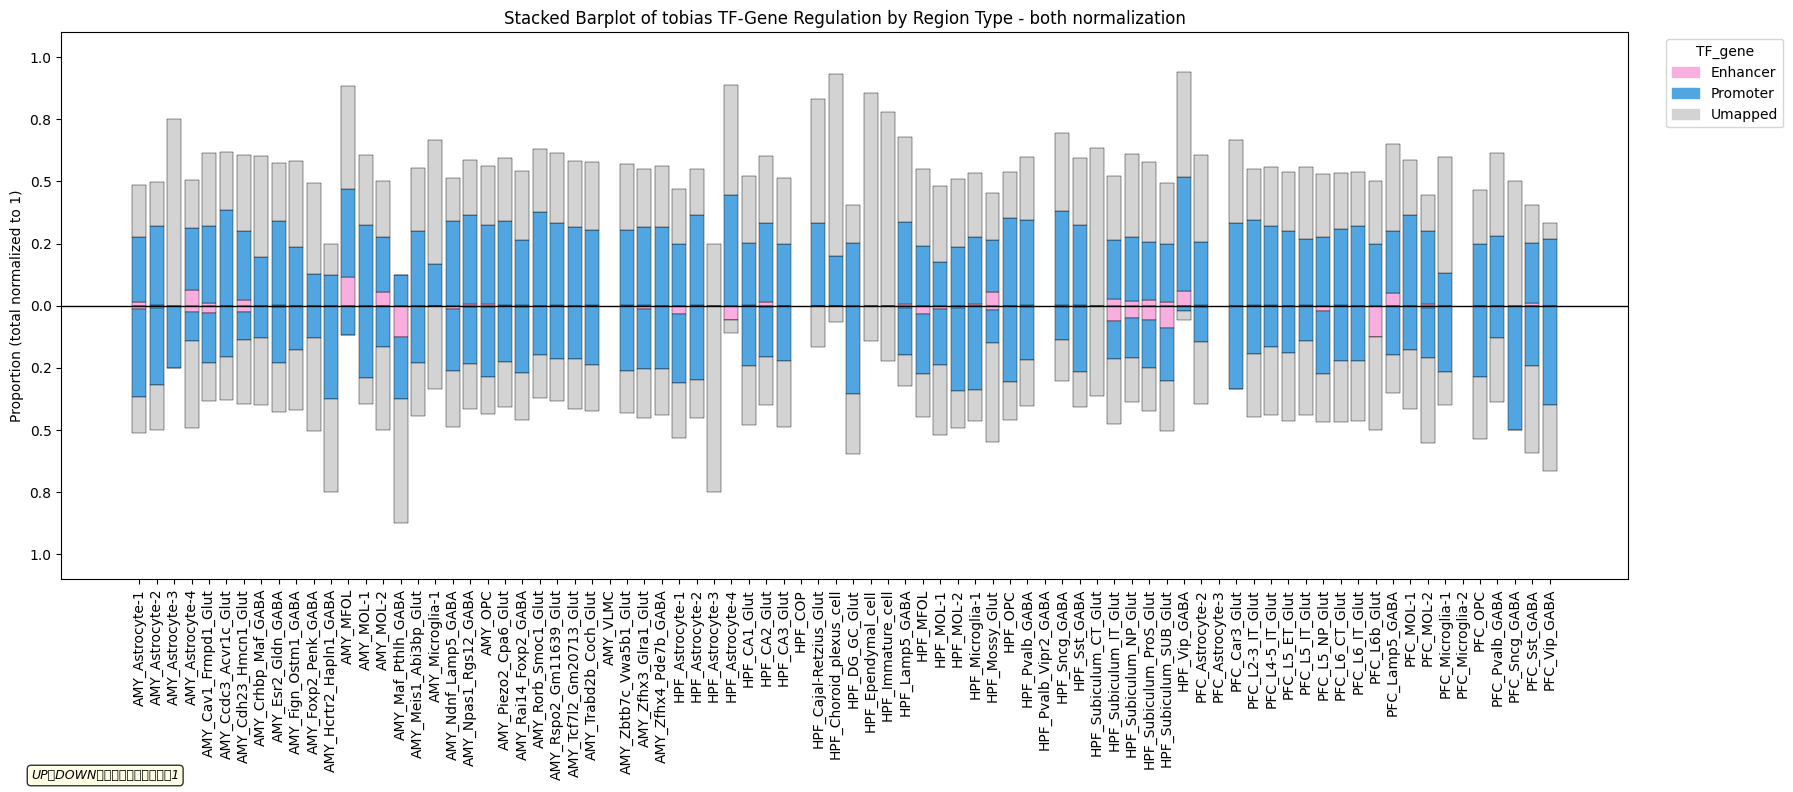

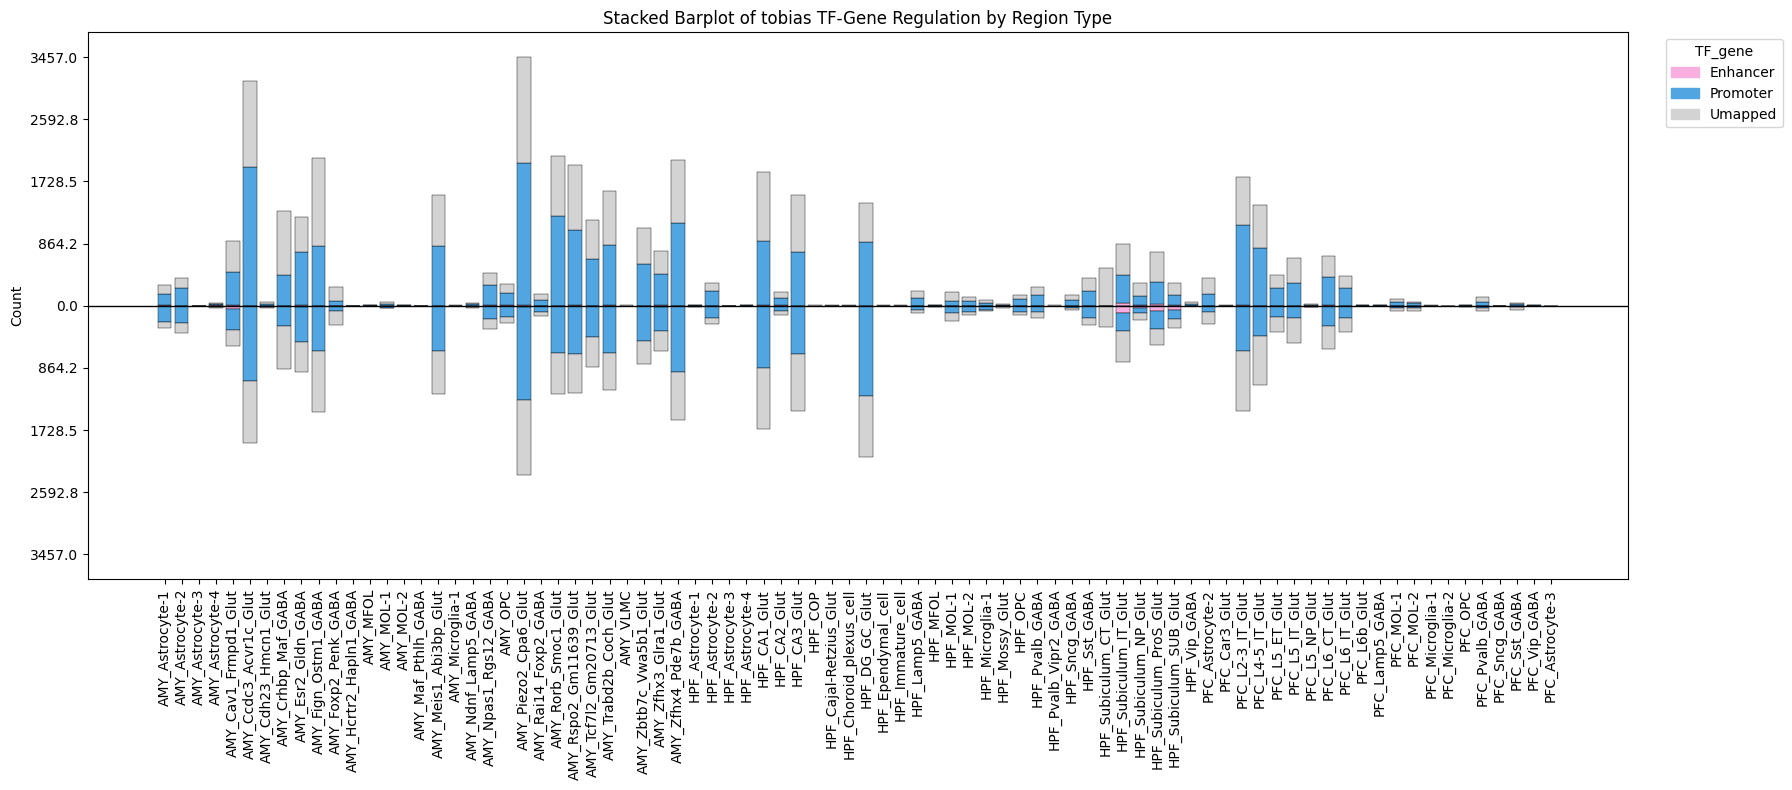

In [285]:
reults= show_stacked_barplot(df_grn_final, column_status="TF_gene",normalize=True,normalize_method="separate",
                             colormap={'Promoter':"#51a6e2",'Enhancer':"#f8aedf",'Umapped':"#d3d3d3"}, 
                             normalize_scale=1, title=f'Stacked Barplot of {exp} TF-Gene Regulation by Region Type',save=f'/data2st1/junyi/output/atac1112/tobias/testdeg/stackedbar_{exp}_sep_tf_gene_regiontype.pdf')
reults= show_stacked_barplot(df_grn_final, column_status="TF_gene",normalize=True,normalize_method="both",
                             colormap={'Promoter':"#51a6e2",'Enhancer':"#f8aedf",'Umapped':"#d3d3d3"}, 
                             normalize_scale=1, title=f'Stacked Barplot of {exp} TF-Gene Regulation by Region Type',save=f'/data2st1/junyi/output/atac1112/tobias/testdeg/stackedbar_{exp}_both_tf_gene_regiontype.pdf')
reults= show_stacked_barplot(df_grn_final, column_status="TF_gene",normalize=False,normalize_method="both",
                             colormap={'Promoter':"#51a6e2",'Enhancer':"#f8aedf",'Umapped':"#d3d3d3"}, 
                             normalize_scale=1, title=f'Stacked Barplot of {exp} TF-Gene Regulation by Region Type',save=f'/data2st1/junyi/output/atac1112/tobias/testdeg/stackedbar_{exp}_non_tf_gene_regiontype.pdf')

# df_deg_merge_promoter_size = df_deg_merge_promoter.groupby(['TF','Region Subclass']).size().reset_index()
# df_deg_pro_select = df_deg_merge_promoter_size[df_deg_merge_promoter_size[0]>10]
# df_deg_merge_promoter_5 = df_deg_merge_promoter.merge(df_deg_pro_select[['TF','Region Subclass']], how='inner', on=['TF','Region Subclass'])
# df_corr, df_pval = summerize_correlation(df_deg_merge_promoter_5, f'{exp}_log2FC', 'log2FC')
# df_corr = pd.DataFrame(list(df_corr.items()), columns=['TF', 'correlation'])
# df_pval = pd.DataFrame(list(df_pval.items()), columns=['TF', 'pvalue'])
# df_corr_pval = pd.merge(df_corr, df_pval, how='inner', on='TF')
# df_corr_pval.to_csv(f'/data2st1/junyi/output/atac1112/tobias/testdeg/correlation_{exp}_filter_tf_gene_promoter.csv', index=False)  


In [296]:
df_group_deg

,Sex,Subclass,Region,Region subclass,Neurotransmitter,Direction,Region subclass_sex_direction,Group,intersection,dataset
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male
1,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G12,"Akt3,Cask,Cnksr2,Dcc,Dgkb,Dmd,Dok6,Erbb4,Faf1,...",CUSUS_male
2,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G2-1,"Adgrb3,Adgrl3,Cacna2d3,Cask,Cnksr2,Ctnna2,Dgkb...",CUSUS_male
3,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G2-4,"Cask,Nlgn1,Nrxn1,Nrxn3,Pclo,Ppfia2,Rims2,Stxbp...",CUSUS_male
4,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G2-5,"Adgrb3,Arhgap32,Cask,Cntn3,Cntn4,Csmd3,Ctnna2,...",CUSUS_male
...,...,...,...,...,...,...,...,...,...,...
1293,M,VLMC,HY,HY VLMC,NN,Down,HY_VLMC_M_Down,other,"Arl6ip1,Rtn1,Rtn4,Arl6ip1,Atp1b1,Bmp6,Caly,Car...",CUSUS_male
1294,M,VLMC,HY,HY VLMC,NN,Up,HY_VLMC_M_Up,G12,"Dnm1l,Rapgef5",CUSUS_male
1295,M,VLMC,HY,HY VLMC,NN,Up,HY_VLMC_M_Up,G4-other,Apoe,CUSUS_male
1296,M,VLMC,HY,HY VLMC,NN,Up,HY_VLMC_M_Up,G5,"Aebp1,Apoe,B2m",CUSUS_male


In [350]:
df_group_deg = pd.read_csv('/data2st1/junyi/output/atac1112/tobias/CUSUS_male_L2level_mannualgroup_BPMF_1209version_deg.tsv', sep='\t')
df_group_deg_selected = df_group_deg[df_group_deg.Region.isin(['HPF','PFC','AMY']) & (df_group_deg.Sex == 'M')]
df_group_deg_selected['Gene'] = df_group_deg_selected['intersection'].str.split(',')
df_group_deg_explode = df_group_deg_selected.explode('Gene')
df_group_deg_explode=df_group_deg_explode


/tmp/ipykernel_3554842/2919960385.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group_deg_selected['Gene'] = df_group_deg_selected['intersection'].str.split(',')


In [351]:
df_group_deg_selected.explode('Gene').shape

(69726, 11)

In [333]:
df_group_deg_explode.head()

,Sex,Subclass,Region,Region subclass,Neurotransmitter,Direction,Region subclass_sex_direction,Group,intersection,dataset,Gene
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Adgrb3
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Adgrl3
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Csmd1
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Dach1
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Dmd


In [352]:
l2deg = glob.glob('/data2st1/junyi/output/atac1112/six_dataset_BPMF_group_level2_genes/*.xlsx')
df_group_deg_nogroup = pd.DataFrame()
for file in l2deg:
    df_tmp = pd.read_excel(file)
    gropu_name = os.path.basename(file).replace('.xlsx','')
    df_tmp['Group'] = gropu_name
    df_group_deg_nogroup = pd.concat([df_group_deg_nogroup, df_tmp], axis=0)

In [353]:
df_group_deg_nogroup['Group_full'] = df_group_deg_nogroup['Group']
df_group_deg_nogroup['Group'] = df_group_deg_nogroup['Group'].str.split(' ').str[0]

In [330]:
df_explode = pd.merge(df_group_deg_explode, df_deg, how='inner', on='Gene')

,Gene,NTreceptor_or_not,NTreceptor_category,ion_or_not,ion_category,Group,Group_full,pval,log2FC,ci.hi,...,Subclass,Region,Sex,Method,Ensemble,Gene_name,Direction,Neurotransmitter,Region subclass,Region Subclass
27,Ano3,No,NaN,Yes,Calcium-activated chloride channel,G4-4,G4-4 chloride,8.172333e-19,-0.117289,-0.091051,...,HPF CA1 Glut,HPF,M,MAST,ENSMUSG00000074968,"""Ano3""",Down,Glut,HPF CA1 Glut,HPF_CA1_Glut
29,Ano3,No,NaN,Yes,Calcium-activated chloride channel,G4-4,G4-4 chloride,9.732601e-06,-0.226410,-0.132131,...,HPF Subiculum NP Glut,HPF,M,MAST,ENSMUSG00000074968,"""Ano3""",Down,Glut,HPF Subiculum NP Glut,HPF_Subiculum_NP_Glut
30,Ano3,No,NaN,Yes,Calcium-activated chloride channel,G4-4,G4-4 chloride,6.966863e-03,-0.177692,-0.063308,...,HPF Subiculum ProS Glut,HPF,M,MAST,ENSMUSG00000074968,"""Ano3""",Down,Glut,HPF Subiculum ProS Glut,HPF_Subiculum_ProS_Glut
31,Ano3,No,NaN,Yes,Calcium-activated chloride channel,G4-4,G4-4 chloride,4.419285e-08,-0.354880,-0.236026,...,HPF Subiculum SUB Glut,HPF,M,MAST,ENSMUSG00000074968,"""Ano3""",Down,Glut,HPF Subiculum SUB Glut,HPF_Subiculum_SUB_Glut
32,Ano3,No,NaN,Yes,Calcium-activated chloride channel,G4-4,G4-4 chloride,1.888238e-03,-0.166860,-0.074485,...,AMY Cav1_Frmpd1 Glut,AMY,M,MAST,ENSMUSG00000074968,"""Ano3""",Down,Glut,AMY Cav1_Frmpd1 Glut,AMY_Cav1_Frmpd1_Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323209,Zyg11b,No,NaN,No,NaN,other,other,8.606449e-06,-0.192712,-0.103963,...,HPF Subiculum IT Glut,HPF,M,MAST,ENSMUSG00000034636,"""Zyg11b""",Down,Glut,HPF Subiculum IT Glut,HPF_Subiculum_IT_Glut
323213,Zyg11b,No,NaN,No,NaN,other,other,3.816091e-04,-0.102493,-0.047170,...,Astrocyte-2,AMY,M,MAST,ENSMUSG00000034636,"""Zyg11b""",Down,NN,AMY Astrocyte-2,AMY_Astrocyte-2
323325,Lypd6b,No,NaN,No,NaN,G2-4,G2-4 neuronal NT,1.190695e-06,0.102421,0.142262,...,AMY Esr2_Gldn GABA,AMY,M,MAST,ENSMUSG00000026765,"""Lypd6b""",Up,GABA,AMY Esr2_Gldn GABA,AMY_Esr2_Gldn_GABA
323327,Lypd6b,No,NaN,No,NaN,G12,G12 signaling,1.190695e-06,0.102421,0.142262,...,AMY Esr2_Gldn GABA,AMY,M,MAST,ENSMUSG00000026765,"""Lypd6b""",Up,GABA,AMY Esr2_Gldn GABA,AMY_Esr2_Gldn_GABA


In [356]:
df_group_deg_explode = df_explode[df_explode.log2FC.abs()>0.1]

In [336]:
def drop_sparse_by_count(df, min_count=2):
    row_mask = (df != 0).sum(axis=1) >= min_count
    col_mask = (df != 0).sum(axis=0) >= min_count
    return df.loc[row_mask, col_mask]

In [337]:
def gen_anno(df,groupby='group',column='Neurotransmitter_x'):
    df_nt = df.drop_duplicates().groupby([groupby,column]).size().reset_index()
    df_nt.columns = [groupby,column,'count']
    df_nt_pivot = df_nt.pivot(index=groupby, columns=column, values='count').fillna(0)
    return df_nt_pivot

In [270]:
df_all_cCRE= pd.concat([df_deg_merge_promoter[["Gene", "Direction", "Region Subclass",'TF','Neurotransmitter','TFBS_chr','TFBS_start','TFBS_end','names','primary_region','log2FC']], 
                        df_deg_merge_proxima[df_deg_merge_proxima.nearproximal=='both'][["Gene", "Direction", "Region Subclass",'TF','Neurotransmitter',
                                                                                         'TFBS_chr','TFBS_start','TFBS_end','names','primary_region','log2FC']]], axis=0)
df_all_cCRE=df_all_cCRE.drop_duplicates()
df_all_cCRE['Region'] = df_all_cCRE['Region Subclass'].str[:3].str.replace('HIP','HPF')


In [271]:
df_all_cCRE_BACK = df_all_cCRE.copy()

In [272]:
df_all_cCRE= df_all_cCRE_BACK#[df_all_cCRE.Region=='NN']


In [273]:
df_all_cCRE.head()

,Gene,Direction,Region Subclass,TF,Neurotransmitter,TFBS_chr,TFBS_start,TFBS_end,names,primary_region,log2FC,Region
2,4732471J01Rik,Up,PFC_Astrocyte-2,Tcf12,NN,chr7,25395949.0,25395958.0,chr7:25395463-25395964,promoter,0.053831,PFC
3,4732471J01Rik,Up,PFC_Astrocyte-2,Jun,NN,chr7,25395934.0,25395945.0,chr7:25395463-25395964,promoter,0.053831,PFC
4,4732471J01Rik,Up,PFC_Astrocyte-2,Tcf7l2,NN,chr7,25395784.0,25395794.0,chr7:25395463-25395964,promoter,0.053831,PFC
5,4833420G17Rik,Up,PFC_Astrocyte-2,Ehf,NN,chr13,119462746.0,119462756.0,chr13:119462463-119462964,promoter,0.040075,PFC
6,4833420G17Rik,Up,PFC_Astrocyte-2,Spdef,NN,chr13,119462746.0,119462756.0,chr13:119462463-119462964,promoter,0.040075,PFC


In [357]:
df_group_deg_explode['Region Subclass'] = df_group_deg_explode['Region subclass'].str.replace(" ","_")

/tmp/ipykernel_3554842/3357980348.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group_deg_explode['Region Subclass'] = df_group_deg_explode['Region subclass'].str.replace(" ","_")


In [358]:
df_module_TFcross = pd.merge(df_all_cCRE,df_group_deg_explode,on=['Region Subclass','Direction','Gene'])
#df_module_TFcross = pd.merge(df_all_cCRE,df_group_deg_explode,how='inner',on=['Gene'])

In [ ]:
df_module_TFcross['BR_Group'] = df_module_TFcross['Region_x'] + '_' + df_module_TFcross['Group']

,Gene,Direction,Region Subclass,TF,Neurotransmitter_x,TFBS_chr,TFBS_start,TFBS_end,names,primary_region,...,FDR,Bonferroni,Subclass,Region_y,Sex,Method,Ensemble,Gene_name,Neurotransmitter_y,Region subclass
0,9430041J12Rik,Down,PFC_Astrocyte-2,Pou6f1,NN,chr7,4120560.0,4120570.0,chr7:4120532-4121033,promoter,...,1.873174e-04,2.266541e-02,Astrocyte-2,PFC,M,MAST,ENSMUSG00000086155,"""9430041J12Rik""",NN,PFC Astrocyte-2
1,9430041J12Rik,Down,PFC_Astrocyte-2,Hoxc10,NN,chr7,4120560.0,4120568.0,chr7:4120532-4121033,promoter,...,1.873174e-04,2.266541e-02,Astrocyte-2,PFC,M,MAST,ENSMUSG00000086155,"""9430041J12Rik""",NN,PFC Astrocyte-2
2,9430041J12Rik,Down,PFC_Astrocyte-2,Stat3,NN,chr7,4120701.0,4120712.0,chr7:4120532-4121033,promoter,...,1.873174e-04,2.266541e-02,Astrocyte-2,PFC,M,MAST,ENSMUSG00000086155,"""9430041J12Rik""",NN,PFC Astrocyte-2
3,9430041J12Rik,Down,PFC_Astrocyte-2,Hic1,NN,chr7,4120758.0,4120767.0,chr7:4120532-4121033,promoter,...,1.873174e-04,2.266541e-02,Astrocyte-2,PFC,M,MAST,ENSMUSG00000086155,"""9430041J12Rik""",NN,PFC Astrocyte-2
4,9430041J12Rik,Down,PFC_Astrocyte-2,Esr2,NN,chr7,4120749.0,4120758.0,chr7:4120532-4121033,promoter,...,1.873174e-04,2.266541e-02,Astrocyte-2,PFC,M,MAST,ENSMUSG00000086155,"""9430041J12Rik""",NN,PFC Astrocyte-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208555,Mfsd2a,Up,AMY_OPC,Spi1,NN,chr4,122958464.0,122958474.0,chr4:122958383-122958884,intron,...,3.601718e-09,2.197048e-07,OPC,AMY,M,MAST,ENSMUSG00000028655,"""Mfsd2a""",NN,AMY OPC
208556,Mfsd2a,Up,AMY_OPC,Spi1,NN,chr4,122958464.0,122958474.0,chr4:122958383-122958884,intron,...,3.601718e-09,2.197048e-07,OPC,AMY,M,MAST,ENSMUSG00000028655,"""Mfsd2a""",NN,AMY OPC
208557,Mfsd2a,Up,AMY_OPC,Spi1,NN,chr4,122958464.0,122958474.0,chr4:122958383-122958884,intron,...,3.601718e-09,2.197048e-07,OPC,AMY,M,MAST,ENSMUSG00000028655,"""Mfsd2a""",NN,AMY OPC
208558,Mfsd2a,Up,AMY_OPC,Spi1,NN,chr4,122958464.0,122958474.0,chr4:122958383-122958884,intron,...,3.601718e-09,2.197048e-07,OPC,AMY,M,MAST,ENSMUSG00000028655,"""Mfsd2a""",NN,AMY OPC


In [360]:
df_module_TFcross_back = df_module_TFcross.copy()

In [370]:
df_module_TFcross = df_module_TFcross_back[df_module_TFcross_back.Region_x=='HPF']

In [372]:
df_module_TFcross = df_module_TFcross_back

In [375]:
df_module_TFcross.columns

Index(['Gene', 'Direction', 'Region Subclass', 'TF', 'Neurotransmitter_x',
       'TFBS_chr', 'TFBS_start', 'TFBS_end', 'names', 'primary_region',
       'log2FC_x', 'Region_x', 'NTreceptor_or_not', 'NTreceptor_category',
       'ion_or_not', 'ion_category', 'Group', 'Group_full', 'pval', 'log2FC_y',
       'ci.hi', 'ci.lo', 'FDR', 'Bonferroni', 'Subclass', 'Region_y', 'Sex',
       'Method', 'Ensemble', 'Gene_name', 'Neurotransmitter_y',
       'Region subclass'],
      dtype='object')

In [51]:
df_merge[df_merge['TF']=='Alx4']

,celltype,motif,width,bgscore,midscore,tfbsscore,Region Subclass Condition,Condtion,Region Subclass,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
41496,HIP_HPF_Pvalb_Vipr2_GABA_MC_corrected,metacluster_118.1cisbp__M00487_None,8.0,-0.00023,-0.00742,-0.00719,HIP_HPF_Pvalb_Vipr2_GABA_MC,MC,HPF_HPF_Pvalb_Vipr2_GABA,metacluster_118.1cisbp__M00487_None,...,Down,-0.00433,M,Alx4,GABA,0.053909,HPF_Pvalb_Vipr2_GABA,HPF,Down,HPF_Pvalb_Vipr2_GABA
41497,HIP_HPF_Pvalb_Vipr2_GABA_MC_corrected,metacluster_118.1cisbp__M00487_None,10.0,0.00107,-0.02028,-0.02134,HIP_HPF_Pvalb_Vipr2_GABA_MC,MC,HPF_HPF_Pvalb_Vipr2_GABA,metacluster_118.1cisbp__M00487_None,...,Down,-0.00433,M,Alx4,GABA,0.053909,HPF_Pvalb_Vipr2_GABA,HPF,Down,HPF_Pvalb_Vipr2_GABA
41498,HIP_HPF_Pvalb_Vipr2_GABA_MC_corrected,metacluster_118.1cisbp__M00487_None,12.0,0.00165,-0.02200,-0.02366,HIP_HPF_Pvalb_Vipr2_GABA_MC,MC,HPF_HPF_Pvalb_Vipr2_GABA,metacluster_118.1cisbp__M00487_None,...,Down,-0.00433,M,Alx4,GABA,0.053909,HPF_Pvalb_Vipr2_GABA,HPF,Down,HPF_Pvalb_Vipr2_GABA
41499,HIP_HPF_Pvalb_Vipr2_GABA_MC_corrected,metacluster_118.1cisbp__M00487_None,14.0,0.00267,-0.02635,-0.02902,HIP_HPF_Pvalb_Vipr2_GABA_MC,MC,HPF_HPF_Pvalb_Vipr2_GABA,metacluster_118.1cisbp__M00487_None,...,Down,-0.00433,M,Alx4,GABA,0.053909,HPF_Pvalb_Vipr2_GABA,HPF,Down,HPF_Pvalb_Vipr2_GABA
41500,HIP_HPF_Pvalb_Vipr2_GABA_MC_corrected,metacluster_118.1cisbp__M00487_None,16.0,0.00458,-0.03512,-0.03971,HIP_HPF_Pvalb_Vipr2_GABA_MC,MC,HPF_HPF_Pvalb_Vipr2_GABA,metacluster_118.1cisbp__M00487_None,...,Down,-0.00433,M,Alx4,GABA,0.053909,HPF_Pvalb_Vipr2_GABA,HPF,Down,HPF_Pvalb_Vipr2_GABA
41501,HIP_HPF_Pvalb_Vipr2_GABA_MC_corrected,metacluster_118.1cisbp__M00487_None,18.0,0.00592,-0.03826,-0.04418,HIP_HPF_Pvalb_Vipr2_GABA_MC,MC,HPF_HPF_Pvalb_Vipr2_GABA,metacluster_118.1cisbp__M00487_None,...,Down,-0.00433,M,Alx4,GABA,0.053909,HPF_Pvalb_Vipr2_GABA,HPF,Down,HPF_Pvalb_Vipr2_GABA
41502,HIP_HPF_Pvalb_Vipr2_GABA_MC_corrected,metacluster_118.1cisbp__M00487_None,20.0,0.00782,-0.04339,-0.05121,HIP_HPF_Pvalb_Vipr2_GABA_MC,MC,HPF_HPF_Pvalb_Vipr2_GABA,metacluster_118.1cisbp__M00487_None,...,Down,-0.00433,M,Alx4,GABA,0.053909,HPF_Pvalb_Vipr2_GABA,HPF,Down,HPF_Pvalb_Vipr2_GABA
41503,HIP_HPF_Pvalb_Vipr2_GABA_MC_corrected,metacluster_118.1cisbp__M00487_None,22.0,0.00773,-0.03831,-0.04604,HIP_HPF_Pvalb_Vipr2_GABA_MC,MC,HPF_HPF_Pvalb_Vipr2_GABA,metacluster_118.1cisbp__M00487_None,...,Down,-0.00433,M,Alx4,GABA,0.053909,HPF_Pvalb_Vipr2_GABA,HPF,Down,HPF_Pvalb_Vipr2_GABA
41504,HIP_HPF_Pvalb_Vipr2_GABA_MC_corrected,metacluster_118.1cisbp__M00487_None,24.0,0.00887,-0.03903,-0.04790,HIP_HPF_Pvalb_Vipr2_GABA_MC,MC,HPF_HPF_Pvalb_Vipr2_GABA,metacluster_118.1cisbp__M00487_None,...,Down,-0.00433,M,Alx4,GABA,0.053909,HPF_Pvalb_Vipr2_GABA,HPF,Down,HPF_Pvalb_Vipr2_GABA
41505,HIP_HPF_Pvalb_Vipr2_GABA_MC_corrected,metacluster_118.1cisbp__M00487_None,26.0,0.00472,-0.02036,-0.02509,HIP_HPF_Pvalb_Vipr2_GABA_MC,MC,HPF_HPF_Pvalb_Vipr2_GABA,metacluster_118.1cisbp__M00487_None,...,Down,-0.00433,M,Alx4,GABA,0.053909,HPF_Pvalb_Vipr2_GABA,HPF,Down,HPF_Pvalb_Vipr2_GABA


In [391]:
df_module_TFcross['Group_full'].unique()

array(['other', 'G1 behavior／response／locomotion／learning／memory',
       'G11 gene expression', 'G2-other neuronal／neuron',
       'G3 glial and other cells', 'G6-1 cytoskeleton',
       'G2-1 neuronal synapse', 'G12 signaling', 'G6-5 cell migration',
       'G6-other', 'G6-4 cell adhesion', 'G2-5 neuronal projection',
       'G5 homeostasis', 'G8-3 apoptotic／cell death',
       'G9 cell proliferation', 'G7-3 cytokine／chemokine',
       'G10 hormone／peptide', 'G7-2 inflammatory response',
       'G7-1 immune response', 'G7-other', 'G2-6 neuronal potential',
       'G4-2 potassium', 'G4-5 ion transport', 'G4-3 sodium',
       'G4-1 calcium', 'G6-2 cell polarity', 'G8-2 ROS',
       'G2-2 neuronal axon', 'G7-4 immune cell', 'G6-3 cell junction',
       'G2-3 neuronal dendrite', 'G8-1 mitochondrion／energy',
       'G4-6 channel', 'G2-4 neuronal NT', 'G4-4 chloride'], dtype=object)

In [428]:
df_module_TFcross.groupby(['Group','TF']).size().reset_index(name='count')

,Group,TF,count
0,G1,Arid3a,130
1,G1,Atf2,162
2,G1,Atf7,56
3,G1,Bhlhe22,17
4,G1,Bhlhe40,220
...,...,...,...
2881,other,Tcf3,566
2882,other,Tcf4,699
2883,other,Tcf7l2,139
2884,other,Tgif2,88


Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 25.930555555555557 mm


<Figure size 1000x200 with 0 Axes>

<Figure size 2000x200 with 0 Axes>

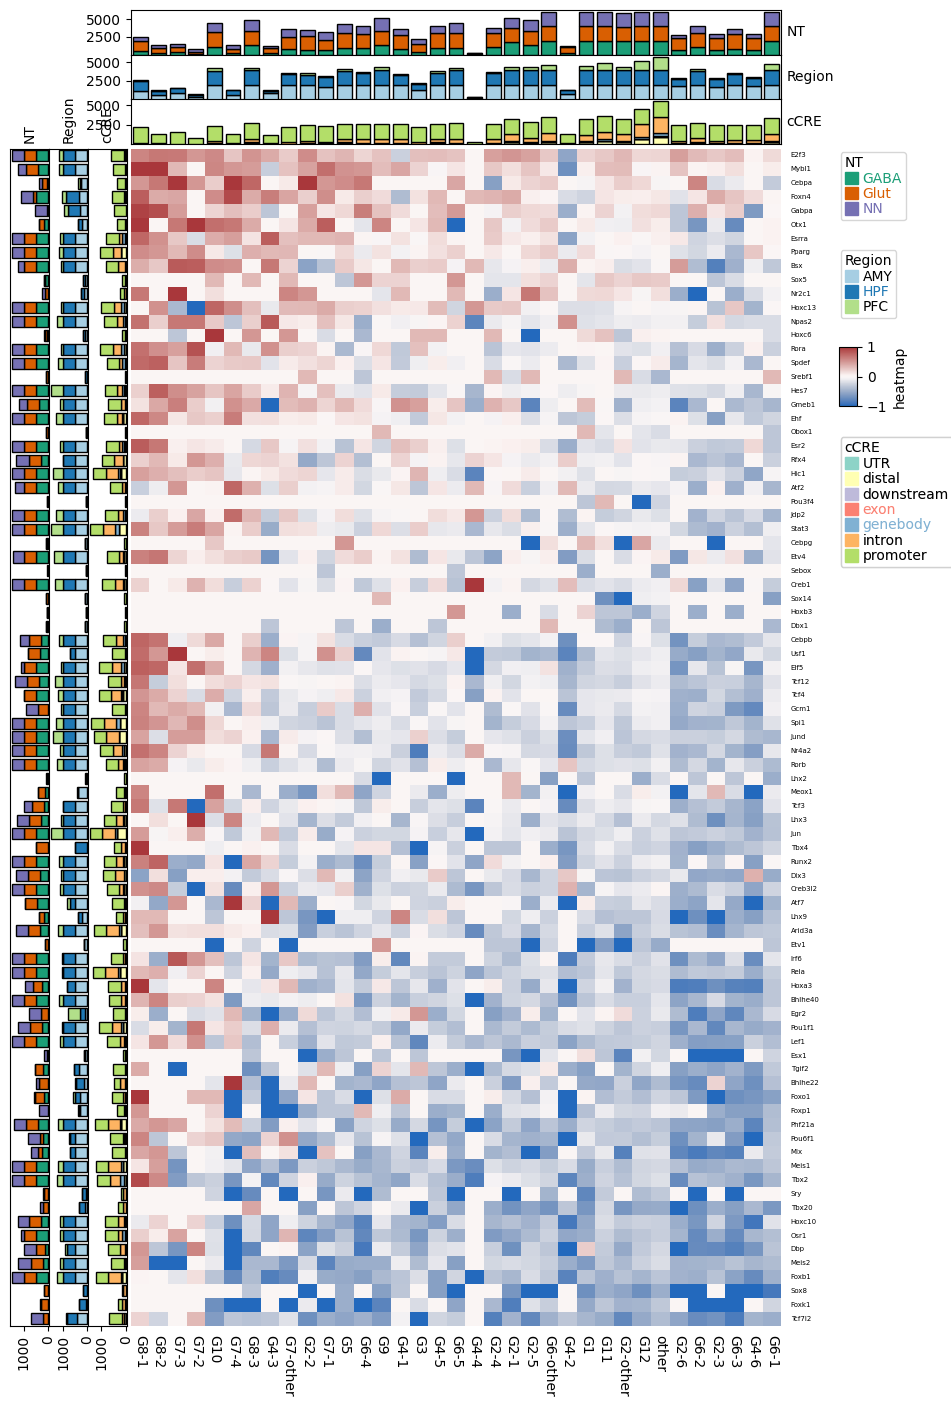

In [425]:
df_count = (
    df_module_TFcross
    .groupby(["Group", "TF"])
    .size()
    .reset_index(name="Gene_count")
)

count_df = (
    df_module_TFcross
    .groupby(["Group", "TF", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 确保列存在
for col in ["Up", "Down"]:
    if col not in count_df.columns:
        count_df[col] = 0

count_df["N_total"] = count_df["Up"] + count_df["Down"]

# 避免除零
count_df["DirectionScore"] = (
    (count_df["Up"] - count_df["Down"]) /
    count_df["N_total"].replace(0, pd.NA)
)
count_df["DirectionScore"] = count_df["DirectionScore"].fillna(0)

MIN_GENES = 3
count_df.loc[count_df["N_total"] < MIN_GENES, "DirectionScore"] = 0

direction_score_matrix = (
    count_df
    .pivot(index="Group", columns="TF", values="DirectionScore")
    .fillna(0)
)

matrix = df_count.pivot(
    index="Group",
    columns="TF",
    values="Gene_count"
).fillna(0).astype(int)

Group=matrix.index.tolist()
# sort Group by group name
df_order= pd.DataFrame({'Group':Group})
df_order['number'] = df_order['Group'].str.split('-').str[0]
df_order['number'] = df_order['number'].str.replace('G','')
df_order['number'] = df_order['number'].str.replace('other','1000')
df_order['number'] = df_order['number'].astype(int)
df_order.sort_values(by=['number','Group'], inplace=True)
direction_score_matrix=direction_score_matrix.loc[df_order['Group'], :]
df_hant = gen_anno(df_module_TFcross,groupby='Group',column='Neurotransmitter_x')
df_region = gen_anno(df_module_TFcross,groupby='Group',column='Region_x')
df_pm = gen_anno(df_module_TFcross,groupby='Group',column='primary_region')


df_ha_t = gen_anno(df_module_TFcross,groupby='TF',column='Neurotransmitter_x')
df_region_t = gen_anno(df_module_TFcross,groupby='TF',column='Region_x')
df_pm_t = gen_anno(df_module_TFcross,groupby='TF',column='primary_region')
order = direction_score_matrix[direction_score_matrix>0].sum(axis=1).sort_values(ascending=False).index
direction_score_matrix= direction_score_matrix.loc[order, :]
order = direction_score_matrix.sum(axis=0).sort_values(ascending=False).index
direction_score_matrix= direction_score_matrix.loc[:,order]

direction_score_matrix = drop_sparse_by_count(direction_score_matrix, min_count=3)
from PyComplexHeatmap import *
plt.figure(figsize=(10, 2))
col_ha = HeatmapAnnotation(
            NT=anno_barplot((df_hant.loc[direction_score_matrix.index].clip(0,2000)).astype(int),legend=True,cmap='Dark2'),
            Region=anno_barplot(df_region.loc[direction_score_matrix.index].clip(0,2000),legend=True,cmap='Paired'),
            cCRE=anno_barplot(df_pm.loc[direction_score_matrix.index].clip(0,2000),legend=True,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,

)
#col_ha.show_ticklabels(direction_score_matrix.index.tolist(),fontdict={'color':'blue'},rotation=-30)
plt.figure(figsize=(20, 2))
row_ha = HeatmapAnnotation(
            NT=anno_barplot((df_ha_t.loc[direction_score_matrix.T.index].clip(0,500)).astype(int),legend=False,cmap='Dark2'),
            Region=anno_barplot(df_region_t.loc[direction_score_matrix.T.index].clip(0,500),legend=False,cmap='Paired'),
            cCRE=anno_barplot(df_pm_t.loc[direction_score_matrix.T.index].clip(0,500),legend=False,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,        axis=0
)
plt.figure(figsize=(10, 15))

cm = ClusterMapPlotter(
        data=direction_score_matrix.T, top_annotation=col_ha,row_cluster=False, col_cluster=False,center=0,left_annotation=row_ha,
        cmap='vlag',
                yticklabels_kws={'labelsize': 5},
        yticklabels=True,
        xticklabels_kws={'labelsize': 10},
        xticklabels=True,
        show_rownames=True,
        show_colnames=True,


)
plt.savefig(f'/data2st1/junyi/output/atac1112/tobias/testdeg/direction_score_matrix_tf_by_module_filtered.pdf',dpi=300)
plt.show()


Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 25.930555555555557 mm


<Figure size 1000x200 with 0 Axes>

<Figure size 2000x200 with 0 Axes>

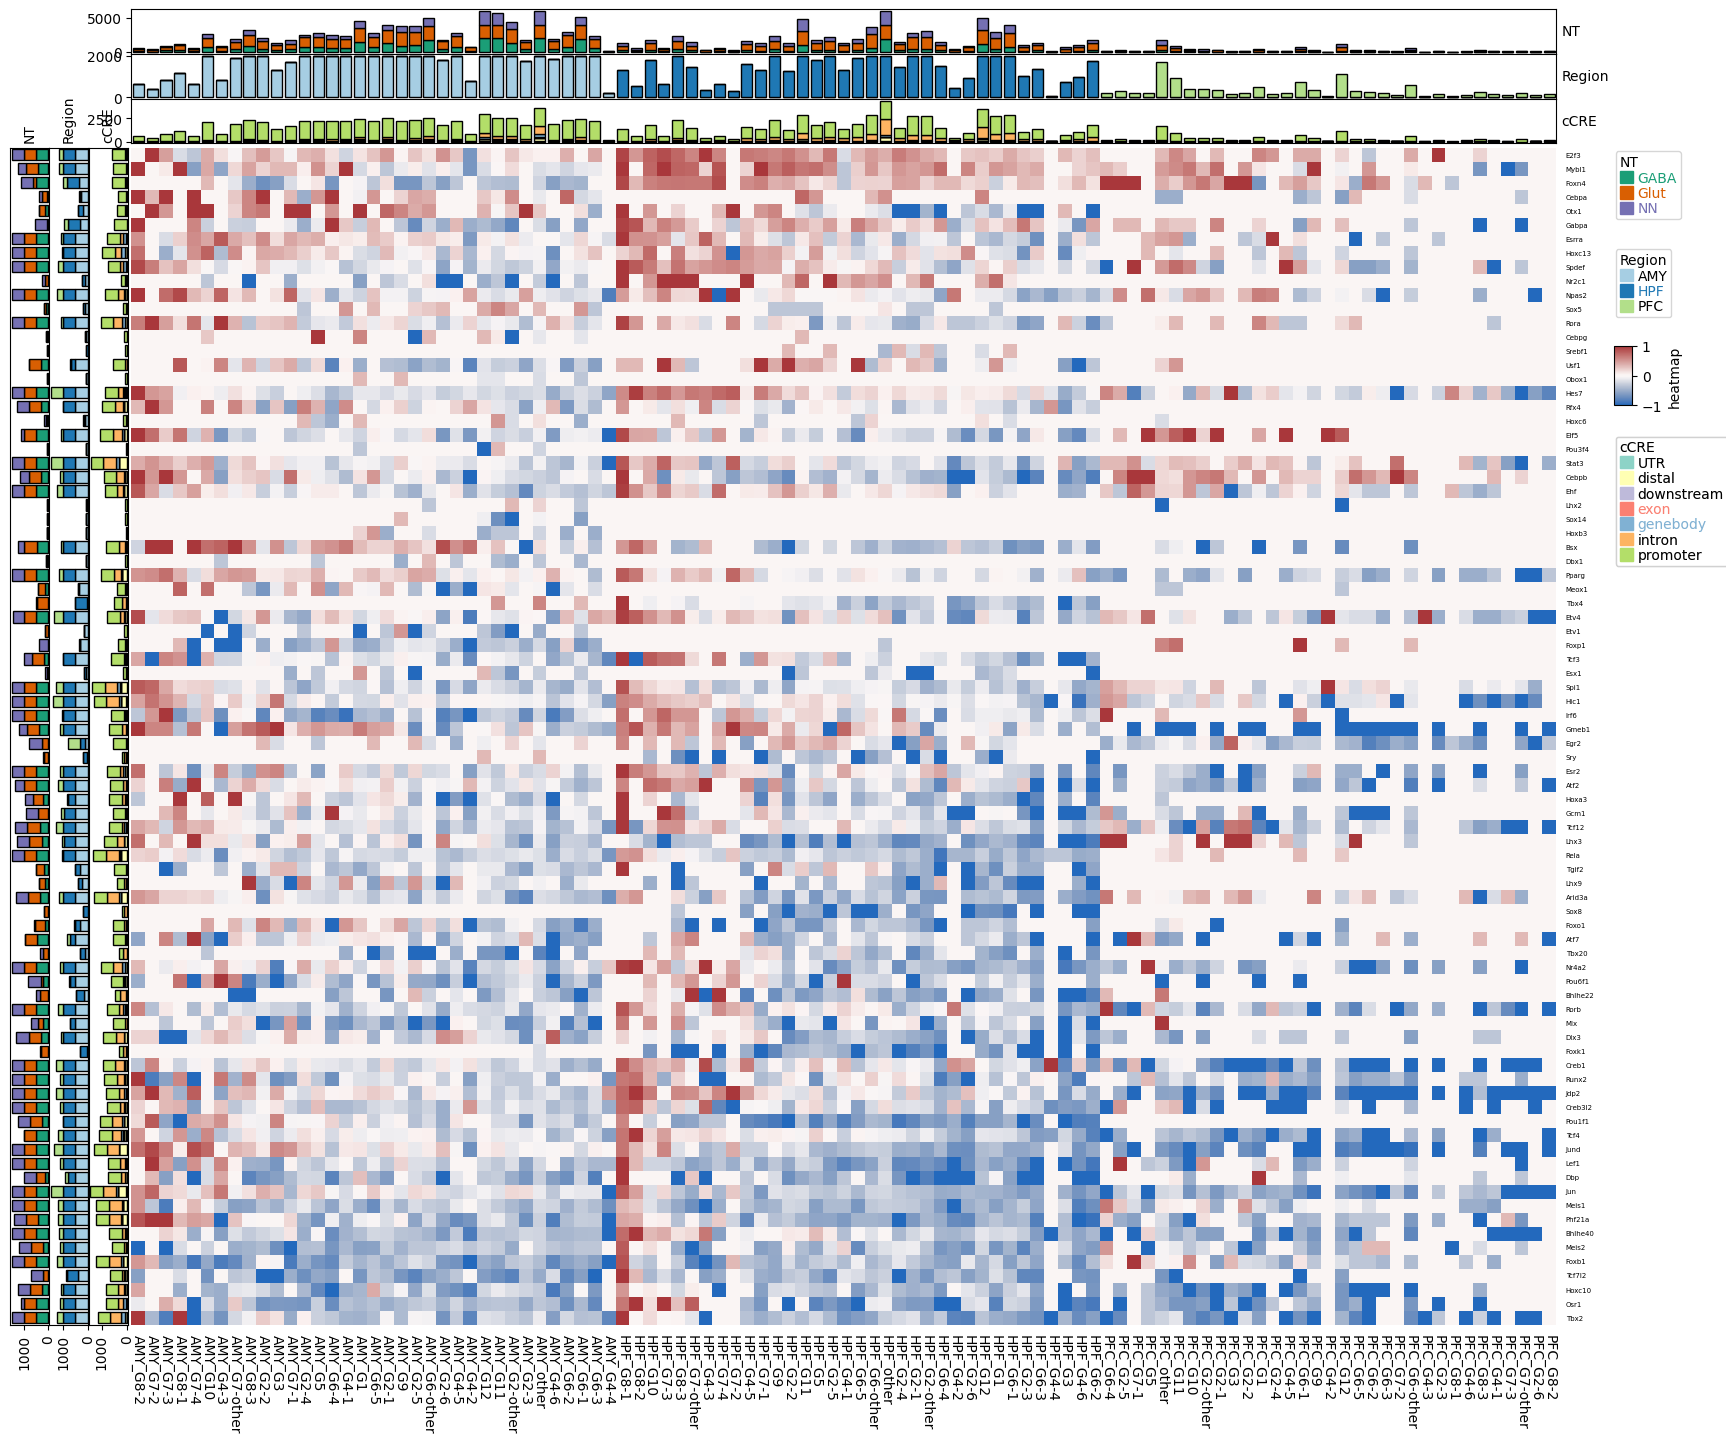

In [424]:
df_count = (
    df_module_TFcross
    .groupby(["BR_Group", "TF"])
    .size()
    .reset_index(name="Gene_count")
)

count_df = (
    df_module_TFcross
    .groupby(["BR_Group", "TF", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 确保列存在
for col in ["Up", "Down"]:
    if col not in count_df.columns:
        count_df[col] = 0

count_df["N_total"] = count_df["Up"] + count_df["Down"]

# 避免除零
count_df["DirectionScore"] = (
    (count_df["Up"] - count_df["Down"]) /
    count_df["N_total"].replace(0, pd.NA)
)
count_df["DirectionScore"] = count_df["DirectionScore"].fillna(0)

MIN_GENES = 3
count_df.loc[count_df["N_total"] < MIN_GENES, "DirectionScore"] = 0

direction_score_matrix = (
    count_df
    .pivot(index="BR_Group", columns="TF", values="DirectionScore")
    .fillna(0)
)

matrix = df_count.pivot(
    index="BR_Group",
    columns="TF",
    values="Gene_count"
).fillna(0).astype(int)

BR_Group=matrix.index.tolist()
# sort BR_Group by group name
df_order= pd.DataFrame({'BR_Group':BR_Group})
# df_order['number'] = df_order['BR_Group'].str.split('-').str[0]
# df_order['number'] = df_order['number'].str.replace('G','')
# df_order['number'] = df_order['number'].str.replace('other','1000')
# df_order['number'] = df_order['number'].astype(int)
df_order.sort_values(by=['BR_Group'], inplace=True)
direction_score_matrix=direction_score_matrix.loc[df_order['BR_Group'], :]
df_hant = gen_anno(df_module_TFcross,groupby='BR_Group',column='Neurotransmitter_x')
df_region = gen_anno(df_module_TFcross,groupby='BR_Group',column='Region_x')
df_pm = gen_anno(df_module_TFcross,groupby='BR_Group',column='primary_region')


df_ha_t = gen_anno(df_module_TFcross,groupby='TF',column='Neurotransmitter_x')
df_region_t = gen_anno(df_module_TFcross,groupby='TF',column='Region_x')
df_pm_t = gen_anno(df_module_TFcross,groupby='TF',column='primary_region')
direction_sum = direction_score_matrix[direction_score_matrix>0].sum(axis=1).to_frame()
direction_sum['Region'] = direction_sum.index.str.split('_').str[0]
direction_sum.sort_values(by=["Region", 0], ascending=[True, False],inplace=True)
direction_score_matrix= direction_score_matrix.loc[direction_sum.index, :]
order = direction_score_matrix.sum(axis=0).sort_values(ascending=False).index
direction_score_matrix= direction_score_matrix.loc[:,order]

# filter clumns with less than 3 values
direction_score_matrix = drop_sparse_by_count(direction_score_matrix, min_count=3)

from PyComplexHeatmap import *
plt.figure(figsize=(10, 2))
col_ha = HeatmapAnnotation(
            NT=anno_barplot((df_hant.loc[direction_score_matrix.index].clip(0,2000)).astype(int),legend=True,cmap='Dark2'),
            Region=anno_barplot(df_region.loc[direction_score_matrix.index].clip(0,2000),legend=True,cmap='Paired'),
            cCRE=anno_barplot(df_pm.loc[direction_score_matrix.index].clip(0,2000),legend=True,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,

)
#col_ha.show_ticklabels(direction_score_matrix.index.tolist(),fontdict={'color':'blue'},rotation=-30)
plt.figure(figsize=(20, 2))
row_ha = HeatmapAnnotation(
            NT=anno_barplot((df_ha_t.loc[direction_score_matrix.T.index].clip(0,500)).astype(int),legend=False,cmap='Dark2'),
            Region=anno_barplot(df_region_t.loc[direction_score_matrix.T.index].clip(0,500),legend=False,cmap='Paired'),
            cCRE=anno_barplot(df_pm_t.loc[direction_score_matrix.T.index].clip(0,500),legend=False,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,        axis=0
)
plt.figure(figsize=(20, 15))

cm = ClusterMapPlotter(
        data=direction_score_matrix.T, top_annotation=col_ha,row_cluster=False, col_cluster=False,center=0,left_annotation=row_ha,
        cmap='vlag',
                yticklabels_kws={'labelsize': 5},
        yticklabels=True,
        xticklabels_kws={'labelsize': 10},
        xticklabels=True,
        show_rownames=True,
        show_colnames=True,


)
plt.savefig(f'/data2st1/junyi/output/atac1112/tobias/testdeg/direction_score_matrix_tf_Region_by_module_filtered.pdf',dpi=300)
plt.show()


In [431]:
# Draw fprint

In [31]:
ct_mmotif = df_merge.drop_duplicates(subset=['celltype','motif','TF','Region'])

In [34]:
for index,row in ct_mmotif.iterrows():
    celltype = row['celltype']
    motif = row['motif']
    celltype = celltype.replace('_corrected','')
    region = celltype.split('_')[0]
    TF = row['TF']
    if "MW" in celltype:
        continue
    #signal = glob.glob(f'/data2st2/junyi/output/atac1112/tobiasbam/*cisbp_BIND/{celltype}*/{motif}/{motif}_all.bed_signal.txt')
    fname = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}cisbp_BIND/{celltype}_footprints.bw/{motif}/beds/{motif}_all.bed_signal.txt'
    df_tmp = pd.read_csv(fname, sep='\t', header=None,skiprows=2)
    df_signal = df_tmp[2].str.split(',',expand=True).astype(float)
    df_signal.index = df_tmp[0]+"_"+TF
    

In [35]:
df_signal

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,,,,,,,,,,,,,,,,,,,,,
AMY_MOL-2_MC_corrected_Gli3,0.0042,0.0128,-0.0102,-0.0032,0.0053,0.0005,0.0069,0.0100,0.0103,-0.0098,...,0.0049,0.0195,0.0018,0.0076,0.0081,0.0211,0.0146,0.0154,0.0017,0.0070
AMY_MOL-2_MW_corrected_Gli3,0.0148,0.0067,-0.0074,0.0134,0.0119,0.0064,0.0092,0.0089,0.0172,0.0041,...,0.0143,0.0087,0.0026,0.0109,0.0158,0.0089,0.0103,0.0068,0.0080,0.0082


In [42]:
x = df_signal.columns

for idx, r in df_signal.iterrows():
    label = idx.split('_')[-3] if '_' in idx else idx
    ax.plot(x, r.values, linewidth=1)

In [43]:
import math
import os
import pandas as pd
import matplotlib.pyplot as plt

for region in ['PFC', 'AMY', 'HPF']:
    for tf in ct_mmotif['TF'].unique():

        df_tf = ct_mmotif[
            (ct_mmotif['TF'] == tf) &
            (ct_mmotif['Region'] == region)
        ]

        if df_tf.shape[0] == 0:
            continue

        # --------- 只保留有效 celltype ----------
        df_tf = df_tf[~df_tf['celltype'].str.contains('MW')]
        if df_tf.shape[0] == 0:
            continue

        n_plots = df_tf.shape[0]
        ncols = 6
        nrows = math.ceil(n_plots / ncols)

        # ===== 创建一个大 figure =====
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(ncols * 2.5, nrows * 2),
            squeeze=False
        )

        axes = axes.flatten()

        # ===== 开始画每个 subplot =====
        for i, (_, row) in enumerate(df_tf.iterrows()):
            ax = axes[i]

            celltype = row['celltype'].replace('_corrected', '')
            motif = row['motif']
            TF = row['TF']
            region2 = celltype.split('_')[0]

            fname = (
                f'/data2st2/junyi/output/atac1112/tobiasbam/'
                f'{region2}cisbp_BIND/{celltype}_footprints.bw/'
                f'{motif}/beds/{motif}_all.bed_signal.txt'
            )

            if not os.path.exists(fname):
                idx.split('_')[-3]
                celltype = celltype.replace('_MC','')
                ax.set_title(celltype, fontsize=8)
                ax.axis('off')
                continue

            df_tmp = pd.read_csv(fname, sep='\t', header=None, skiprows=2)
            df_signal = df_tmp[2].str.split(',', expand=True).astype(float)
            df_signal.index = df_tmp[0] + "_" + TF

            x = df_signal.columns

            for idx, r in df_signal.iterrows():
                label = idx.split('_')[-3] if '_' in idx else idx
                ax.plot(x, r.values, linewidth=1)
            for v in [55, 60, 65]:
                ax.axvline(v, color='grey', linestyle='--', linewidth=0.8)

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(celltype.replace('_MC',''), fontsize=8)

        # --------- 多余的空 subplot 关掉 ----------
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        # ===== 总标题 =====
        fig.suptitle(f'{tf} footprints ({region})', fontsize=14)

        # ===== 保存 =====
        outdir = f'/data2st1/junyi/output/atac1112/tobias/plots/{region}/{tf}'
        os.makedirs(outdir, exist_ok=True)

        outfile = f'{outdir}/{tf}_footprints_all_celltypes.pdf'
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        fig.savefig(outfile, dpi=300)
        plt.close(fig)


KeyboardInterrupt: 

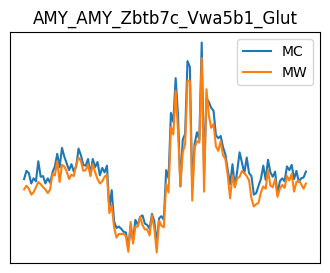

In [ ]:
# for region in ['PFC','AMY','HPF']:
#     for tf in ct_mmotif['TF'].unique():
#         os.makedirs(f'/data2st1/junyi/output/atac1112/tobias/plots/{region}/{tf}', exist_ok=True)

#         df_tmp = ct_mmotif[(ct_mmotif['TF']==tf) & (ct_mmotif['Region']==region)]
#         if df_tmp.shape[0]==0:
#             continue

#         for index,row in df_tmp.iterrows():
#             celltype = row['celltype']
#             motif = row['motif']
#             celltype = celltype.replace('_corrected','')
#             region = celltype.split('_')[0]
#             TF = row['TF']
#             if "MW" in celltype:
#                 continue
#             #signal = glob.glob(f'/data2st2/junyi/output/atac1112/tobiasbam/*cisbp_BIND/{celltype}*/{motif}/{motif}_all.bed_signal.txt')
#             fname = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}cisbp_BIND/{celltype}_footprints.bw/{motif}/beds/{motif}_all.bed_signal.txt'
#             df_tmp = pd.read_csv(fname, sep='\t', header=None,skiprows=2)
#             df_signal = df_tmp[2].str.split(',',expand=True).astype(float)
#             df_signal.index = df_tmp[0]+"_"+TF
            

#             fig  = plt.figure(figsize=(4, 3))
#             x = df_signal.columns
#             for idx, row in df_signal.iterrows():
#                 plt.plot(x, row.values, label=idx.split('_')[-3])
#             #plt.tight_layout()
#             plt.xticks([])          # ⬅ hide x ticks
#             plt.yticks([])          # ⬅ hide x ticks
#             plt.legend()
#             title = idx.replace
#             legeng = idx.split('_MW')[0]
#             plt.title(f'{legeng}')
#             plt.savefig(f'/data2st1/junyi/output/atac1112/tobias/plots/{region}/{tf}/{celltype}_footprint_plot.pdf',dpi=300)    
#             plt.close(fig)  # 不显示，关闭图形


In [529]:
df_signal

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,,,,,,,,,,,,,,,,,,,,,
HIP_MOL-1_MC_corrected_Rorb,0.0190,0.0197,0.0124,0.0168,0.0178,0.0054,0.0259,0.0215,0.0231,0.0089,...,0.0197,0.0177,0.0220,0.0148,0.0165,0.0275,0.0240,0.0191,0.0213,0.0274
HIP_MOL-1_MW_corrected_Rorb,0.0116,0.0229,0.0206,0.0288,0.0144,0.0075,0.0245,0.0239,0.0224,0.0201,...,0.0312,0.0253,0.0262,0.0206,0.0142,0.0206,0.0346,0.0185,0.0354,0.0286


'MW'

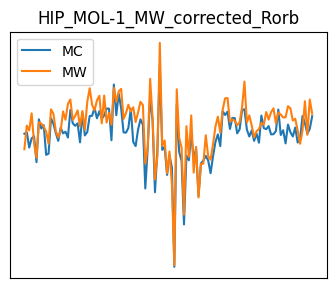

In [510]:
idx

'AMY_MOL-2_MW_corrected_Gli3'

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,0.0042,0.0128,-0.0102,-0.0032,0.0053,0.0005,0.0069,0.0100,0.0103,-0.0098,...,0.0049,0.0195,0.0018,0.0076,0.0081,0.0211,0.0146,0.0154,0.0017,0.0070
1,0.0148,0.0067,-0.0074,0.0134,0.0119,0.0064,0.0092,0.0089,0.0172,0.0041,...,0.0143,0.0087,0.0026,0.0109,0.0158,0.0089,0.0103,0.0068,0.0080,0.0082


In [ ]:
df

,0,1,2
0,AMY_MOL-2_MC_corrected,metacluster_181.1cisbp__M08023_None_all,"0.0042,0.0128,-0.0102,-0.0032,0.0053,0.0005,0...."
1,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None_all,"0.0148,0.0067,-0.0074,0.0134,0.0119,0.0064,0.0..."
